## Import Library

In [1]:
import pandas as pd
import numpy as np
import gradio as gr
import io, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os

warnings.filterwarnings("ignore")


from statsmodels.tsa.arima.model import ARIMA # Added for ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

c:\Users\Ridho\Documents\Ridho\Codingan\Python\Python Versi 3.14\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
# ── SEL 2: Upload Dataset Harian ──────────────
import os

folder_data = "data"

df_list = []

for filename in os.listdir(folder_data):

    filepath = os.path.join(folder_data, filename)

    if filename.endswith(".csv"):
        temp = pd.read_csv(filepath)

    elif filename.endswith(".xlsx") or filename.endswith(".xls"):
        temp = pd.read_excel(filepath)

    else:
        continue

    df_list.append(temp)
    print("Berhasil dibaca:", filename)

df = pd.concat(df_list, ignore_index=True)

df["tanggal"] = pd.to_datetime(df["tanggal"])
df = df.sort_values(["tanggal", "nama_kereta"]).reset_index(drop=True)
# ── TAMBAHAN: Buat Lonjakan Penumpang Agar Ada Tambahan Gerbong ──

df["is_event_besar"] = 0

# Faktor lonjakan awal
df["faktor_lonjakan"] = 1.0

# Weekend lebih ramai
df.loc[df["is_weekend"] == 1, "faktor_lonjakan"] *= 1.25

# Libur sekolah
df.loc[df["is_libur_sekolah"] == 1, "faktor_lonjakan"] *= 1.30

# Libur akhir tahun
df.loc[df["is_libur_akhir_tahun"] == 1, "faktor_lonjakan"] *= 1.50

# Lebaran paling ramai
df.loc[df["is_lebaran"] == 1, "faktor_lonjakan"] *= 2.20

# Event besar acak 8% data
np.random.seed(42)
df["is_event_besar"] = np.random.choice(
    [0, 1],
    size=len(df),
    p=[0.92, 0.08]
)

df.loc[df["is_event_besar"] == 1, "faktor_lonjakan"] *= 1.80

# Terapkan ke jumlah penumpang
df["jumlah_penumpang"] = (
    df["jumlah_penumpang"] * df["faktor_lonjakan"]
).astype(int)

# Hitung ulang gerbong
df["gerbong_dibutuhkan"] = np.ceil(df["jumlah_penumpang"] / 80).astype(int)

df["tambahan_gerbong"] = (
    df["gerbong_dibutuhkan"] - df["gerbong_tersedia"]
).clip(lower=0)

df["gerbong_dibutuhkan"] = np.ceil(df["jumlah_penumpang"] / 80).astype(int)

df["tambahan_gerbong"] = (
    df["gerbong_dibutuhkan"] - df["gerbong_tersedia"]
).clip(lower=0)

kolom_dipilih = ["tanggal", "nama_kereta", "kapasitas_kursi", "jumlah_penumpang", "gerbong_tersedia"]
display(df[kolom_dipilih].head(20))



Berhasil dibaca: cleaned_Data_Kereta.csv
Berhasil dibaca: dataset_kereta_harian_2017.xlsx
Berhasil dibaca: dataset_kereta_harian_2018.xlsx
Berhasil dibaca: dataset_kereta_harian_2019.xlsx
Berhasil dibaca: dataset_kereta_harian_2020.xlsx
Berhasil dibaca: dataset_kereta_harian_2021.xlsx
Berhasil dibaca: dataset_kereta_harian_2022.xlsx
Berhasil dibaca: dataset_kereta_harian_2023.xlsx
Berhasil dibaca: dataset_kereta_harian_2024.xlsx
Berhasil dibaca: dataset_kereta_harian_2025.xlsx


,tanggal,nama_kereta,kapasitas_kursi,jumlah_penumpang,gerbong_tersedia
0,2017-01-01,Argo Bromo Anggrek,600,1133,8
1,2017-01-01,Argo Bromo Anggrek,600,9531,8
2,2017-01-01,Argo Bromo Anggrek,600,726,8
3,2017-01-01,Argo Bromo Anggrek,600,581,8
4,2017-01-01,Argo Bromo Anggrek,600,465,8
5,2017-01-01,Jayabaya,1000,3145,13
6,2017-01-01,Jayabaya,1000,1397,13
7,2017-01-01,Jayabaya,1000,1118,13
8,2017-01-01,Jayabaya,1000,895,13
9,2017-01-01,Jayabaya,1000,716,13


In [3]:
print("===== Info Dataset =====")
print(df.info())

print("\n===== Ukuran Dataset =====")
print(df.shape)

print("\n===== Nama Kolom =====")
print(df.columns)

===== Info Dataset =====
<class 'pandas.DataFrame'>
RangeIndex: 82175 entries, 0 to 82174
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal               82175 non-null  datetime64[us]
 1   tahun                 82175 non-null  int64         
 2   bulan                 82175 non-null  int64         
 3   hari                  82175 non-null  int64         
 4   nama_kereta           82175 non-null  str           
 5   kapasitas_kursi       82175 non-null  int64         
 6   jumlah_penumpang      82175 non-null  int64         
 7   is_weekend            82175 non-null  int64         
 8   is_lebaran            82175 non-null  int64         
 9   is_libur_sekolah      82175 non-null  int64         
 10  is_libur_akhir_tahun  82175 non-null  int64         
 11  gerbong_dibutuhkan    82175 non-null  int64         
 12  gerbong_tersedia      82175 non-null  int64         
 13  ta

In [4]:
print("=== CEK MISSING VALUE ===")
print(df.isnull().sum())
print("\n")

print("=== CEK STRING KOSONG ===")
print((df == '').sum())

print("=== CEK STRING DIISI SPASI ===")
print((df.apply(lambda x: x.astype(str).str.strip() == '')).sum())

print("=== cek duplikat ===")
print(df.duplicated().sum())

=== CEK MISSING VALUE ===
tanggal                     0
tahun                       0
bulan                       0
hari                        0
nama_kereta                 0
kapasitas_kursi             0
jumlah_penumpang            0
is_weekend                  0
is_lebaran                  0
is_libur_sekolah            0
is_libur_akhir_tahun        0
gerbong_dibutuhkan          0
gerbong_tersedia            0
tambahan_gerbong            0
is_event_besar              0
faktor_lonjakan             0
hari_ke                 16435
bulan_sin               16435
bulan_cos               16435
kereta_code             16435
dtype: int64


=== CEK STRING KOSONG ===
tanggal                 0
tahun                   0
bulan                   0
hari                    0
nama_kereta             0
kapasitas_kursi         0
jumlah_penumpang        0
is_weekend              0
is_lebaran              0
is_libur_sekolah        0
is_libur_akhir_tahun    0
gerbong_dibutuhkan      0
gerbong_tersedia     

## EDA

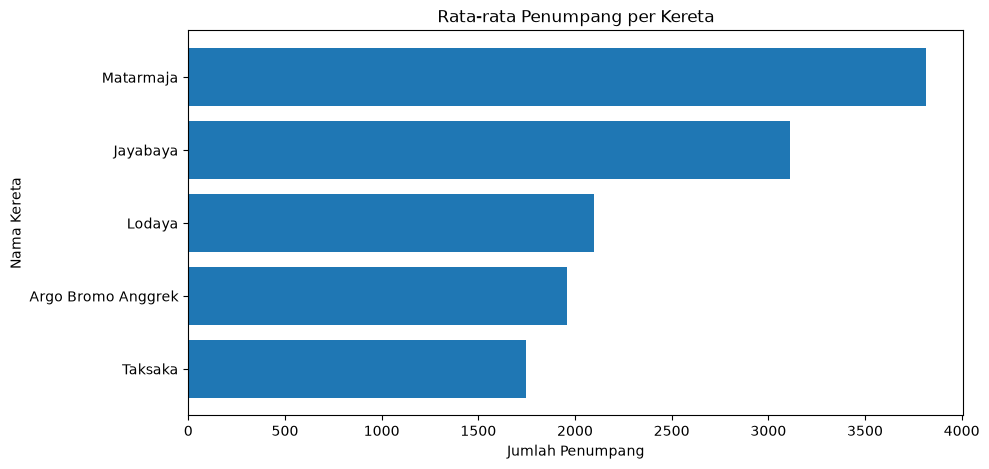

In [5]:
def grafik_kereta():
    data = df.groupby("nama_kereta")["jumlah_penumpang"].mean().sort_values()

    plt.figure(figsize=(10, 5))
    plt.barh(data.index, data.values)
    plt.title("Rata-rata Penumpang per Kereta")
    plt.xlabel("Jumlah Penumpang")
    plt.ylabel("Nama Kereta")
    plt.show()

grafik_kereta()

=== Histogram Jumlah Penumpang ===


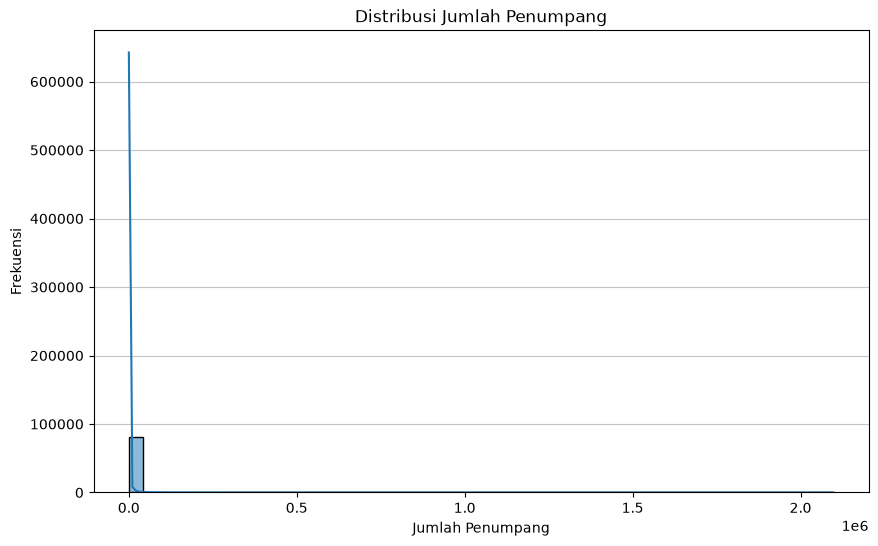

In [6]:
print("=== Histogram Jumlah Penumpang ===")
plt.figure(figsize=(10, 6))
sns.histplot(df['jumlah_penumpang'], bins=50, kde=True)
plt.title('Distribusi Jumlah Penumpang')
plt.xlabel('Jumlah Penumpang')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.75)
plt.show()

=== Countplot Nama Kereta ===


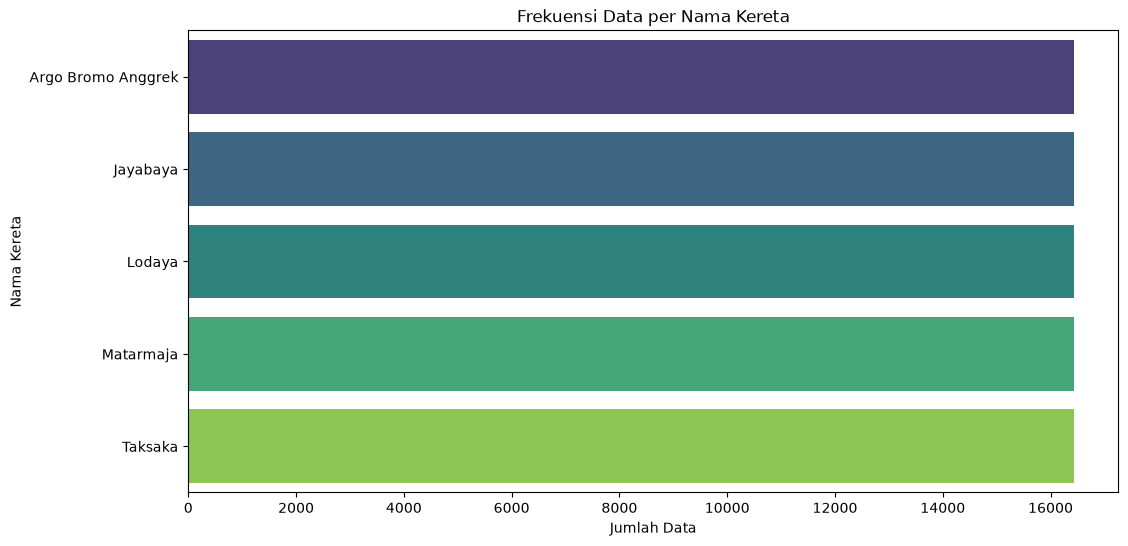

In [7]:
print("=== Countplot Nama Kereta ===")
plt.figure(figsize=(12, 6))
sns.countplot(y=df['nama_kereta'], order=df['nama_kereta'].value_counts().index, palette='viridis')
plt.title('Frekuensi Data per Nama Kereta')
plt.xlabel('Jumlah Data')
plt.ylabel('Nama Kereta')
plt.show()

=== Proporsi Event ===


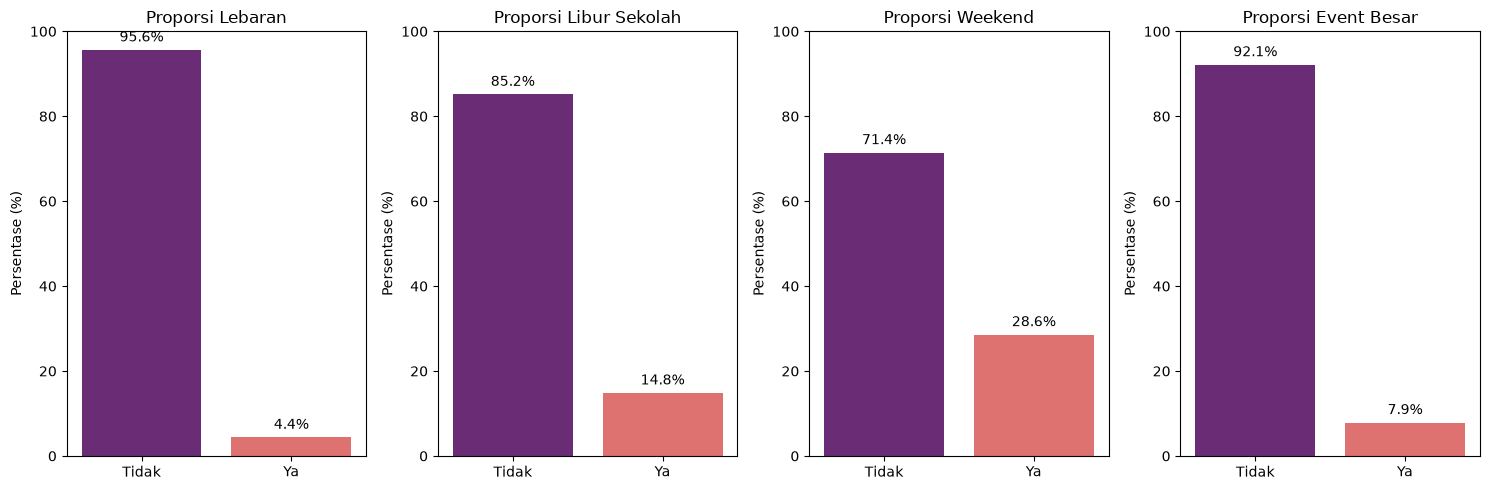

In [8]:
print("=== Proporsi Event ===")

event_cols = ['is_lebaran', 'is_libur_sekolah', 'is_weekend', 'is_event_besar']

plt.figure(figsize=(15, 5))

for i, col in enumerate(event_cols):
    plt.subplot(1, len(event_cols), i + 1)

    # Menghitung proporsi (persentase)
    prop = df[col].value_counts(normalize=True).mul(100).reset_index()
    prop.columns = ['value', 'percentage']

    # Membuat bar chart
    sns.barplot(x='value', y='percentage', data=prop, palette='magma')
    plt.title(f'Proporsi {col.replace("is_", "").replace("_", " ").title()}')
    plt.xlabel('') # Menghilangkan label x karena sudah ada di judul
    plt.ylabel('Persentase (%)')
    plt.xticks([0, 1], ['Tidak', 'Ya'])
    plt.ylim(0, 100)

    # Menambahkan label persentase di atas bar
    for index, row in prop.iterrows():
        plt.text(row.name, row.percentage + 2, f'{row.percentage:.1f}%', color='black', ha="center")

plt.tight_layout()
plt.show()

### Tren Waktu (Time Series)

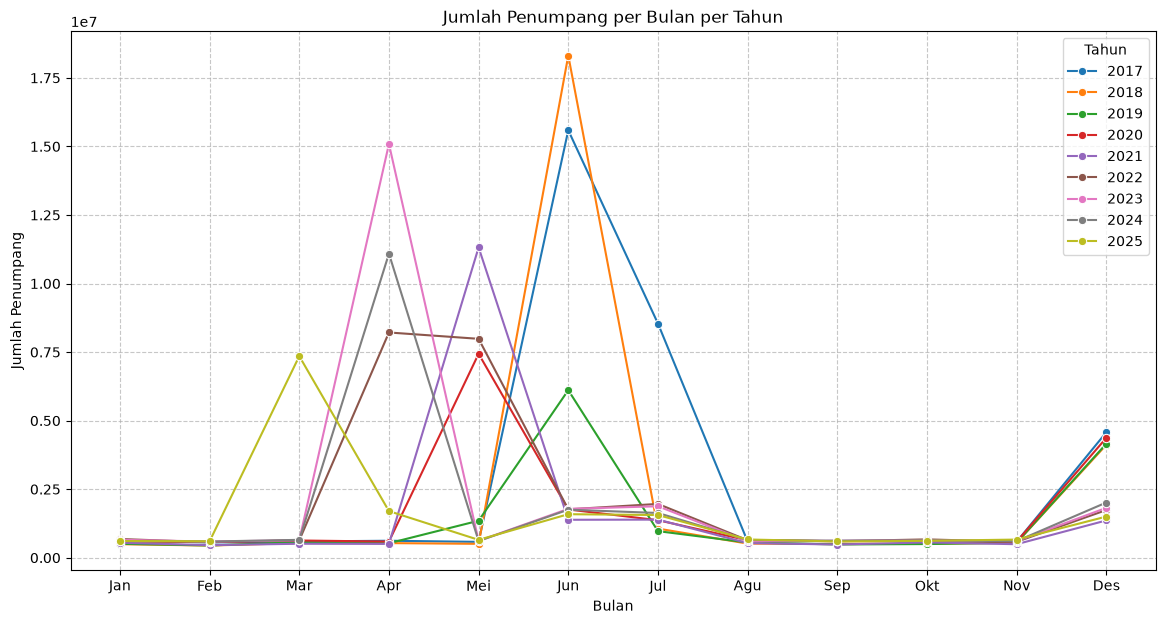

In [9]:
# 1. Agregasi data dengan menamai level indeksnya secara langsung
df_monthly_yearly = (
    df.groupby([df['tanggal'].dt.year.rename('tahun'),
                df['tanggal'].dt.month.rename('bulan')])['jumlah_penumpang']
    .sum()
    .reset_index()
)

# Sekarang df_monthly_yearly sudah memiliki kolom 'tahun', 'bulan', dan 'jumlah_penumpang'
# Anda tidak perlu lagi mengganti nama kolom secara manual.

# 2. Plotting
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_monthly_yearly, x='bulan', y='jumlah_penumpang', hue='tahun', palette='tab10', marker='o')

plt.title('Jumlah Penumpang per Bulan per Tahun')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penumpang')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Tahun')
plt.show()

=== Heatmap Rata-rata Penumpang (Bulan vs Tahun) ===


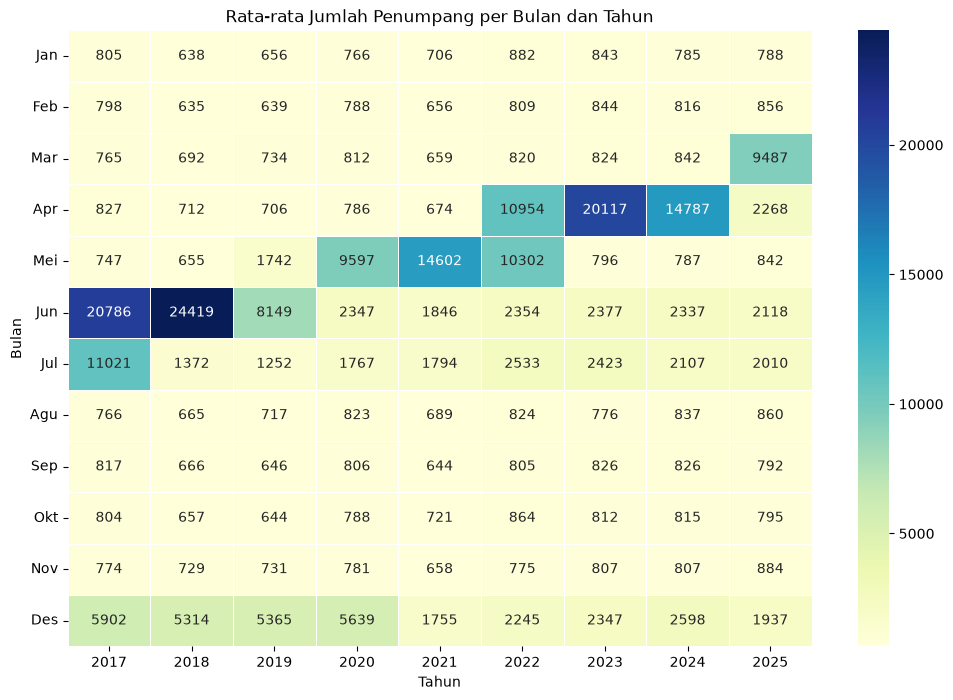

In [10]:
print("=== Heatmap Rata-rata Penumpang (Bulan vs Tahun) ===")

# Membuat pivot table untuk rata-rata penumpang per bulan dan tahun
df_heatmap = df.pivot_table(index=df['tanggal'].dt.month, columns=df['tanggal'].dt.year, values='jumlah_penumpang', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=.5)
plt.title('Rata-rata Jumlah Penumpang per Bulan dan Tahun')
plt.xlabel('Tahun')
plt.ylabel('Bulan')
plt.yticks(ticks=np.arange(12) + 0.5, labels=['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'], rotation=0)
plt.show()

### Perbandingan Antar Kategori (Bivariate)

=== Boxplot Jumlah Penumpang per Nama Kereta ===


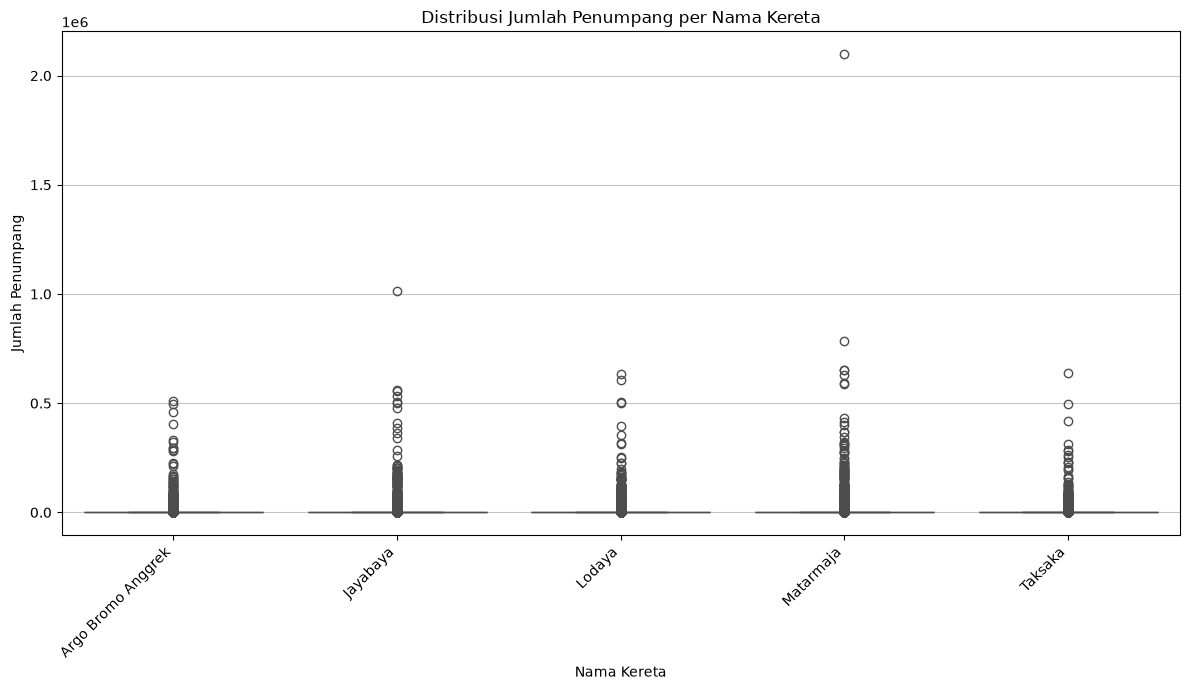

In [11]:
print("=== Boxplot Jumlah Penumpang per Nama Kereta ===")
plt.figure(figsize=(12, 7))
sns.boxplot(x='nama_kereta', y='jumlah_penumpang', data=df, palette='Spectral')
plt.title('Distribusi Jumlah Penumpang per Nama Kereta')
plt.xlabel('Nama Kereta')
plt.ylabel('Jumlah Penumpang')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

=== Boxplot Jumlah Penumpang vs Status Event ===


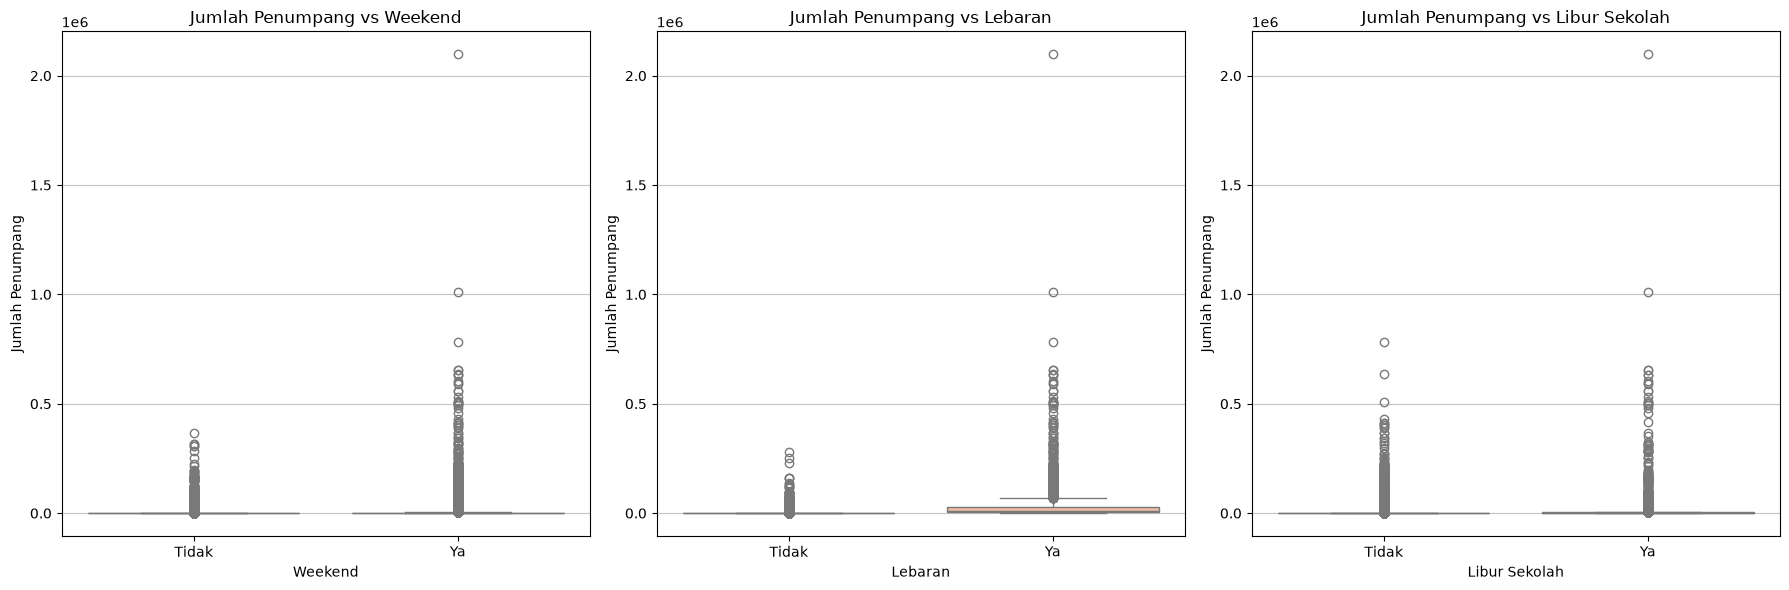

In [12]:
print("=== Boxplot Jumlah Penumpang vs Status Event ===")

event_flags = ['is_weekend', 'is_lebaran', 'is_libur_sekolah']

plt.figure(figsize=(18, 6))

for i, flag in enumerate(event_flags):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=flag, y='jumlah_penumpang', data=df, palette='coolwarm')
    plt.title(f'Jumlah Penumpang vs {flag.replace("is_", "").replace("_", " ").title()}')
    plt.xlabel(flag.replace("is_", "").replace("_", " ").title())
    plt.ylabel('Jumlah Penumpang')
    plt.xticks([0, 1], ['Tidak', 'Ya'])
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

=== Bar Chart Rata-rata Faktor Lonjakan per Nama Kereta ===


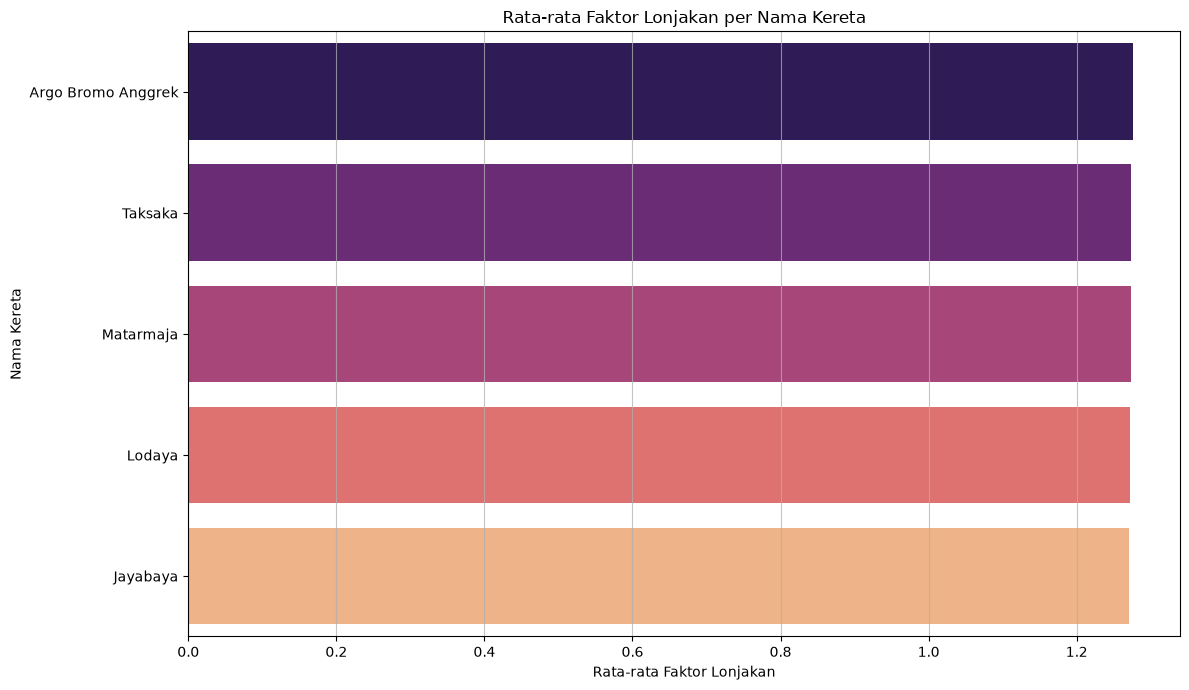

In [13]:
print("=== Bar Chart Rata-rata Faktor Lonjakan per Nama Kereta ===")
df_avg_faktor_lonjakan = df.groupby('nama_kereta')['faktor_lonjakan'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='faktor_lonjakan', y='nama_kereta', data=df_avg_faktor_lonjakan, palette='magma')
plt.title('Rata-rata Faktor Lonjakan per Nama Kereta')
plt.xlabel('Rata-rata Faktor Lonjakan')
plt.ylabel('Nama Kereta')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

### Korelasi dan Hubungan Antar Variabel

=== Heatmap Korelasi Antar Kolom Numerik ===


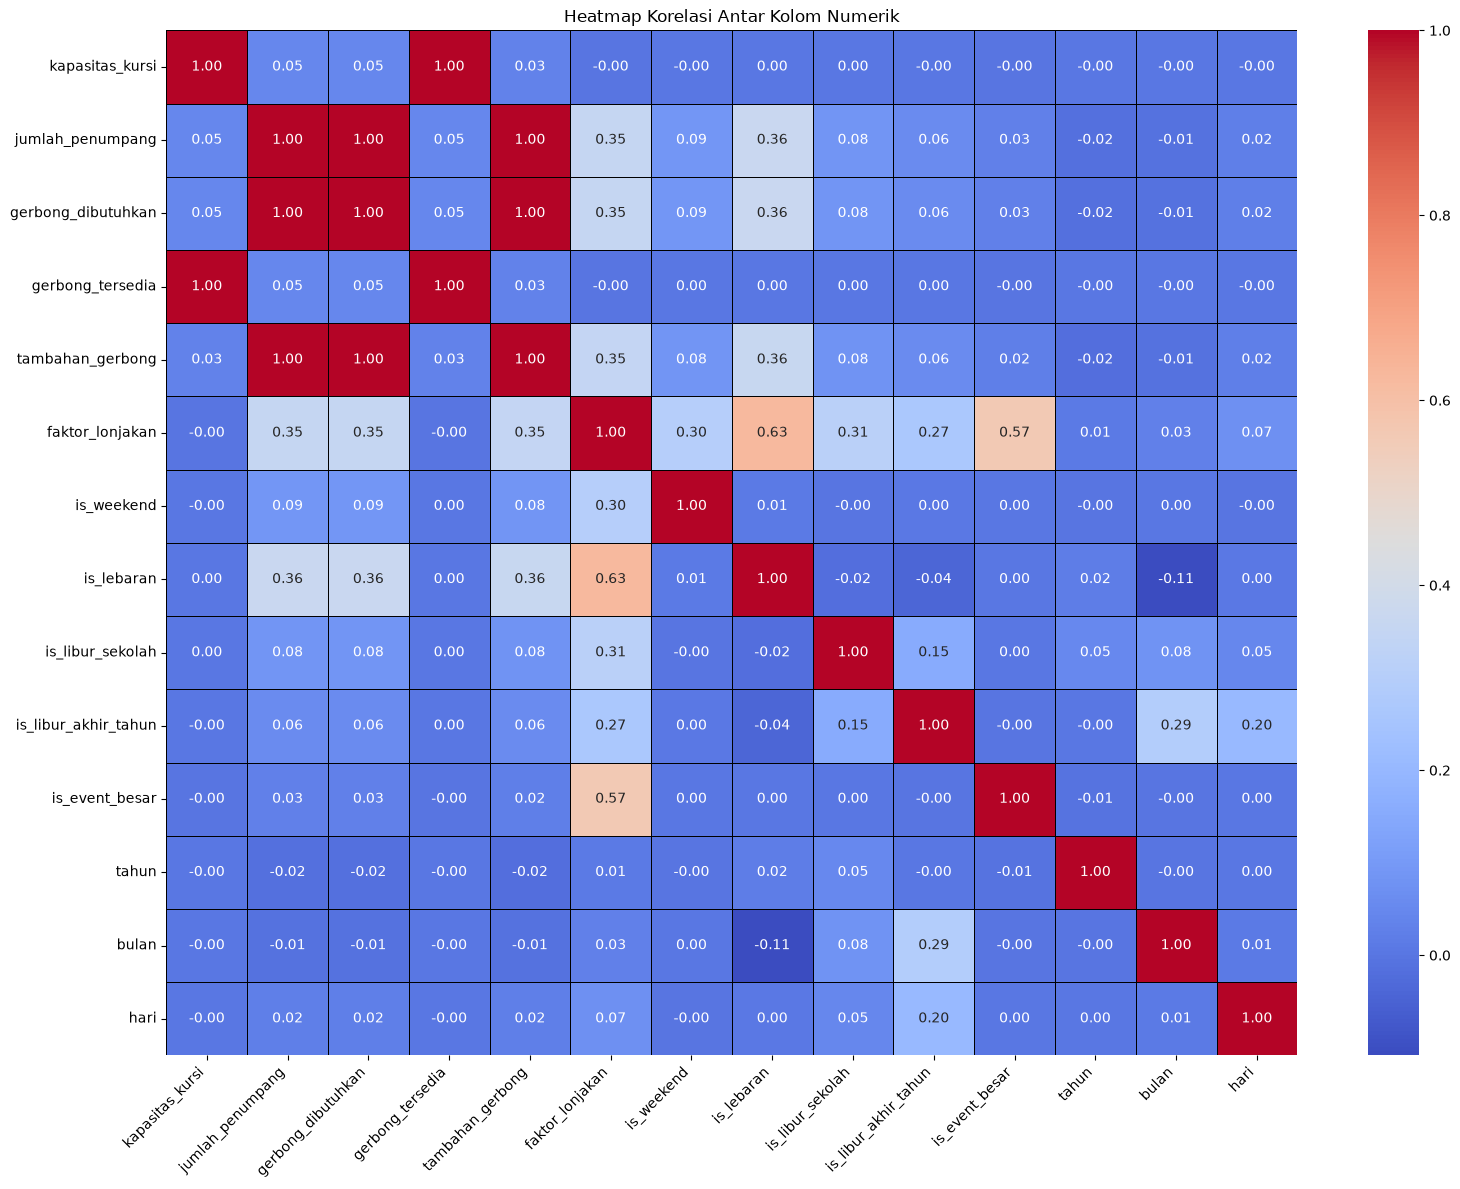

In [14]:
print("=== Heatmap Korelasi Antar Kolom Numerik ===")

# Memilih kolom numerik untuk matriks korelasi
numerical_cols_for_corr = [
    'kapasitas_kursi',
    'jumlah_penumpang',
    'gerbong_dibutuhkan',
    'gerbong_tersedia',
    'tambahan_gerbong',
    'faktor_lonjakan',
    'is_weekend',
    'is_lebaran',
    'is_libur_sekolah',
    'is_libur_akhir_tahun',
    'is_event_besar',
    'tahun',
    'bulan',
    'hari'
]

# Filter kolom yang benar-benar ada di DataFrame
actual_numerical_cols = [col for col in numerical_cols_for_corr if col in df.columns]

correlation_matrix_full = df[actual_numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix_full,
    annot=True, # Menampilkan nilai korelasi
    cmap="coolwarm",
    fmt=".2f", # Format dua desimal
    linewidths=.5,
    linecolor='black'
)
plt.title("Heatmap Korelasi Antar Kolom Numerik")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== Scatter Plot Kapasitas Kursi vs Jumlah Penumpang ===


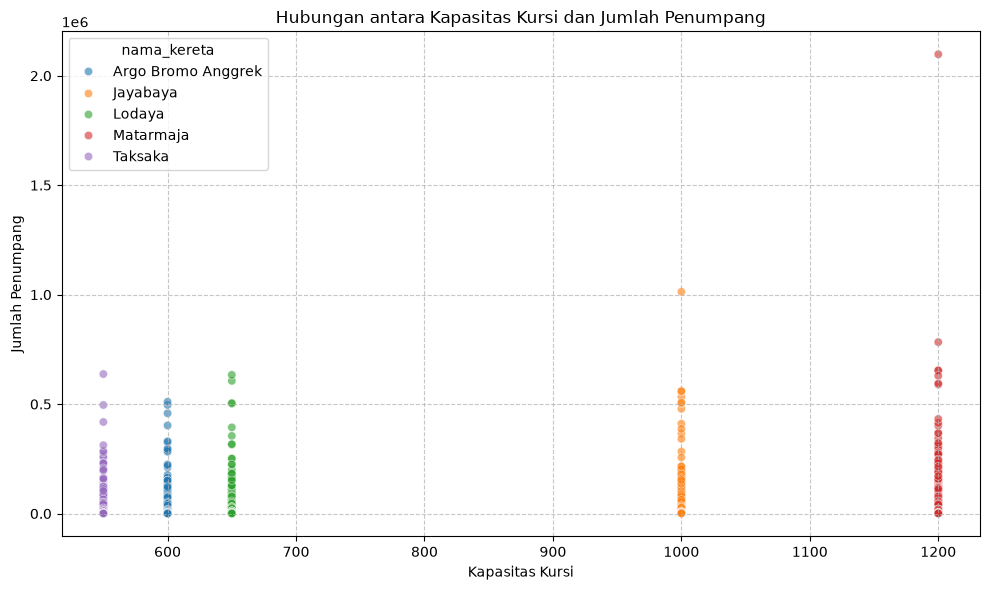

In [15]:
print("=== Scatter Plot Kapasitas Kursi vs Jumlah Penumpang ===")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='kapasitas_kursi', y='jumlah_penumpang', data=df, alpha=0.6, hue='nama_kereta', palette='tab10')
plt.title('Hubungan antara Kapasitas Kursi dan Jumlah Penumpang')
plt.xlabel('Kapasitas Kursi')
plt.ylabel('Jumlah Penumpang')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analisis Kapasitas dan Gerbong

=== Bar Chart Tambahan Gerbong per Bulan ===


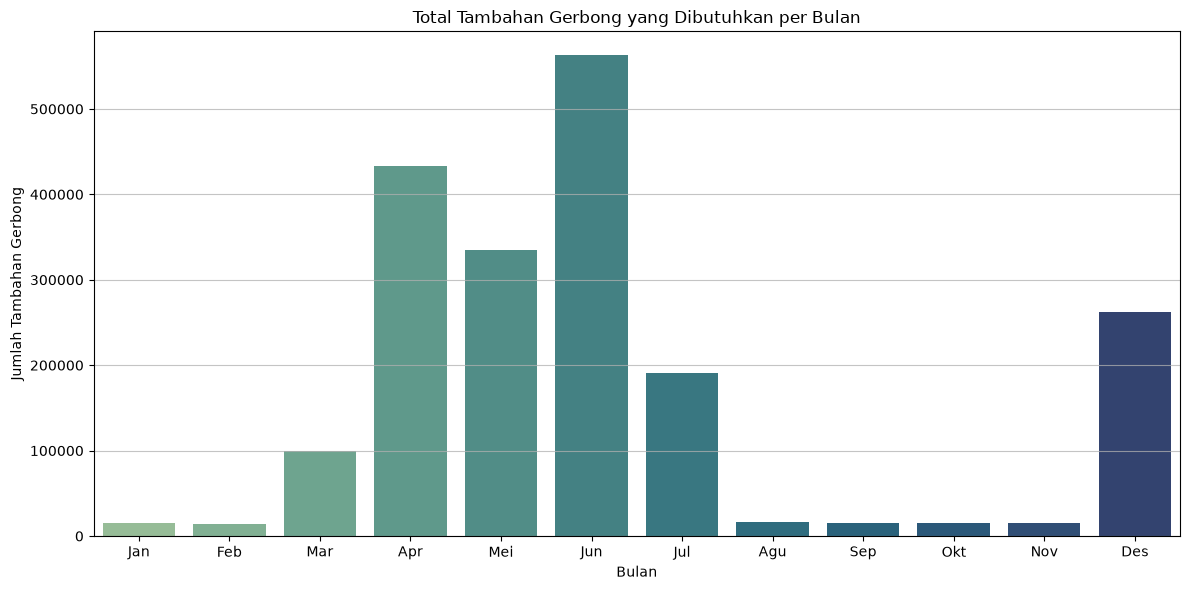

In [16]:
print("=== Bar Chart Tambahan Gerbong per Bulan ===")

# Agregasi jumlah tambahan gerbong per bulan
df_tambahan_gerbong_bulan = df.groupby('bulan')['tambahan_gerbong'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='bulan', y='tambahan_gerbong', data=df_tambahan_gerbong_bulan, palette='crest')
plt.title('Total Tambahan Gerbong yang Dibutuhkan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Tambahan Gerbong')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

=== Stacked Bar Chart Gerbong Tersedia vs Dibutuhkan per Bulan ===


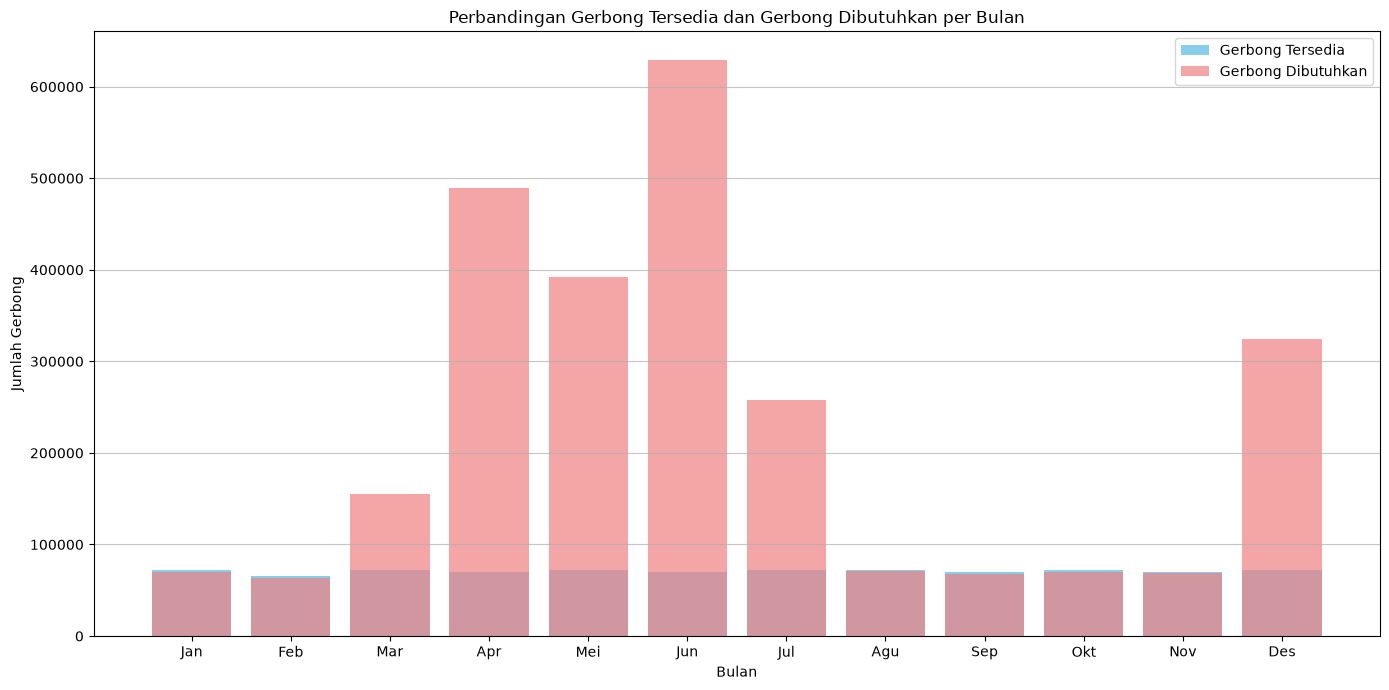

In [17]:
print("=== Stacked Bar Chart Gerbong Tersedia vs Dibutuhkan per Bulan ===")

# Agregasi gerbong tersedia dan dibutuhkan per bulan
df_gerbong_bulan = df.groupby('bulan')[['gerbong_tersedia', 'gerbong_dibutuhkan']].sum().reset_index()

# Membuat kolom 'gap' untuk visualisasi
df_gerbong_bulan['gap_negatif'] = df_gerbong_bulan['gerbong_tersedia'] - df_gerbong_bulan['gerbong_dibutuhkan']

plt.figure(figsize=(14, 7))
bar_tersedia = plt.bar(df_gerbong_bulan['bulan'], df_gerbong_bulan['gerbong_tersedia'], color='skyblue', label='Gerbong Tersedia')
bar_dibutuhkan = plt.bar(df_gerbong_bulan['bulan'], df_gerbong_bulan['gerbong_dibutuhkan'], color='lightcoral', label='Gerbong Dibutuhkan', alpha=0.7)

plt.title('Perbandingan Gerbong Tersedia dan Gerbong Dibutuhkan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Gerbong')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Preparation

In [18]:
# ── SEL 3: Feature Engineering ────────────────
df["tahun"] = df["tanggal"].dt.year
df["bulan"] = df["tanggal"].dt.month
df["hari"] = df["tanggal"].dt.day
df["hari_ke"] = df["tanggal"].dt.dayofweek  # Senin=0
df["is_weekend"] = df["hari_ke"].isin([5,6]).astype(int)

df["bulan_sin"] = np.sin(2 * np.pi * df["bulan"] / 12)
df["bulan_cos"] = np.cos(2 * np.pi * df["bulan"] / 12)

df["kereta_code"] = df["nama_kereta"].astype("category").cat.codes
kereta_map = dict(enumerate(df["nama_kereta"].astype("category").cat.categories))

FITUR = [
    "tahun",
    "bulan",
    "hari",
    "hari_ke",
    "is_weekend",
    "is_lebaran",
    "is_libur_sekolah",
    "is_libur_akhir_tahun",
    "kapasitas_kursi",
    "gerbong_tersedia",
    "bulan_sin",
    "bulan_cos",
    "kereta_code"
]

X = df[FITUR]
y = df["jumlah_penumpang"]

In [19]:
# ── SEL 5: Feature Engineering Harian ─────────
def buat_fitur(df):
    d = df.copy().sort_values(["nama_kereta", "tanggal"]).reset_index(drop=True)

    d["tahun"] = d["tanggal"].dt.year
    d["bulan"] = d["tanggal"].dt.month
    d["hari"] = d["tanggal"].dt.day
    d["hari_ke"] = d["tanggal"].dt.dayofweek
    d["minggu_ke"] = d["tanggal"].dt.isocalendar().week.astype(int)

    d["bulan_sin"] = np.sin(2 * np.pi * d["bulan"] / 12)
    d["bulan_cos"] = np.cos(2 * np.pi * d["bulan"] / 12)
    d["hari_sin"] = np.sin(2 * np.pi * d["hari"] / 31)
    d["hari_cos"] = np.cos(2 * np.pi * d["hari"] / 31)

    d["kereta_code"] = d["nama_kereta"].astype("category").cat.codes

    d["lag_1"] = d.groupby("nama_kereta")["jumlah_penumpang"].shift(1)
    d["lag_7"] = d.groupby("nama_kereta")["jumlah_penumpang"].shift(7)
    d["lag_30"] = d.groupby("nama_kereta")["jumlah_penumpang"].shift(30)
    d["roll_7"] = d.groupby("nama_kereta")["jumlah_penumpang"].shift(1).rolling(7).mean()
    d["roll_30"] = d.groupby("nama_kereta")["jumlah_penumpang"].shift(1).rolling(30).mean()

    return d.dropna().reset_index(drop=True)

df_feat = buat_fitur(df)

FITUR_COLS = [
    "tahun", "bulan", "hari", "hari_ke", "minggu_ke",
    "is_weekend", "is_lebaran", "is_libur_sekolah",
    "is_event_besar","is_libur_akhir_tahun",
    "kapasitas_kursi", "gerbong_tersedia",
    "bulan_sin", "bulan_cos", "hari_sin", "hari_cos",
    "kereta_code",
    "lag_1", "lag_7", "lag_30", "roll_7", "roll_30"
]

print(f"✓ Fitur dibuat: {len(df_feat)} baris siap training")
display(df_feat.head())

✓ Fitur dibuat: 82025 baris siap training


,tanggal,tahun,bulan,hari,nama_kereta,kapasitas_kursi,jumlah_penumpang,is_weekend,is_lebaran,is_libur_sekolah,...,bulan_cos,kereta_code,minggu_ke,hari_sin,hari_cos,lag_1,lag_7,lag_30,roll_7,roll_30
0,2017-01-07,2017,1,7,Argo Bromo Anggrek,600,1300,1,0,0,...,0.866025,0,1,0.988468,0.151428,319.0,324.0,1133.0,356.857143,715.200000
1,2017-01-07,2017,1,7,Argo Bromo Anggrek,600,1040,1,0,0,...,0.866025,0,1,0.988468,0.151428,1300.0,324.0,9531.0,496.285714,720.766667
2,2017-01-07,2017,1,7,Argo Bromo Anggrek,600,832,1,0,0,...,0.866025,0,1,0.988468,0.151428,1040.0,574.0,726.0,598.571429,437.733333
3,2017-01-07,2017,1,7,Argo Bromo Anggrek,600,666,1,0,0,...,0.866025,0,1,0.988468,0.151428,832.0,319.0,581.0,635.428571,441.266667
4,2017-01-07,2017,1,7,Argo Bromo Anggrek,600,960,1,0,0,...,0.866025,0,1,0.988468,0.151428,666.0,319.0,465.0,685.000000,444.100000


## Modeling

Train-Test Split (Time Series)

In [20]:
# Pisahkan data train dan test (80:20 berdasarkan urutan waktu)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Jumlah data train :", len(X_train))
print("Jumlah data test  :", len(X_test))

Jumlah data train : 65740
Jumlah data test  : 16435


In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

Training Model

In [23]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

Prediksi

In [24]:
y_pred = rf_model.predict(X_test)

## Evaluasi

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

MAE  : 1744.90
RMSE : 11081.65
MAPE : 70.12%
R²   : 0.2459


In [26]:
hasil = X_test.copy()

hasil["Actual"] = y_test.values
hasil["Prediction"] = y_pred

hasil.head(10)

,tahun,bulan,hari,hari_ke,is_weekend,is_lebaran,is_libur_sekolah,is_libur_akhir_tahun,kapasitas_kursi,gerbong_tersedia,bulan_sin,bulan_cos,kereta_code,Actual,Prediction
65740,2024,3,14,3,0,0,0,0,1200,15,1.0,6.123234e-17,3,869,945.350972
65741,2024,3,14,3,0,0,0,0,1200,15,1.0,6.123234e-17,3,869,945.350972
65742,2024,3,14,3,0,0,0,0,1200,15,1.0,6.123234e-17,3,1564,945.350972
65743,2024,3,14,3,0,0,0,0,1200,15,1.0,6.123234e-17,3,869,945.350972
65744,2024,3,14,3,0,0,0,0,1200,15,1.0,6.123234e-17,3,869,945.350972
65745,2024,3,14,3,0,0,0,0,550,7,1.0,6.123234e-17,4,295,388.483782
65746,2024,3,14,3,0,0,0,0,550,7,1.0,6.123234e-17,4,295,388.483782
65747,2024,3,14,3,0,0,0,0,550,7,1.0,6.123234e-17,4,295,388.483782
65748,2024,3,14,3,0,0,0,0,550,7,1.0,6.123234e-17,4,295,388.483782
65749,2024,3,14,3,0,0,0,0,550,7,1.0,6.123234e-17,4,295,388.483782


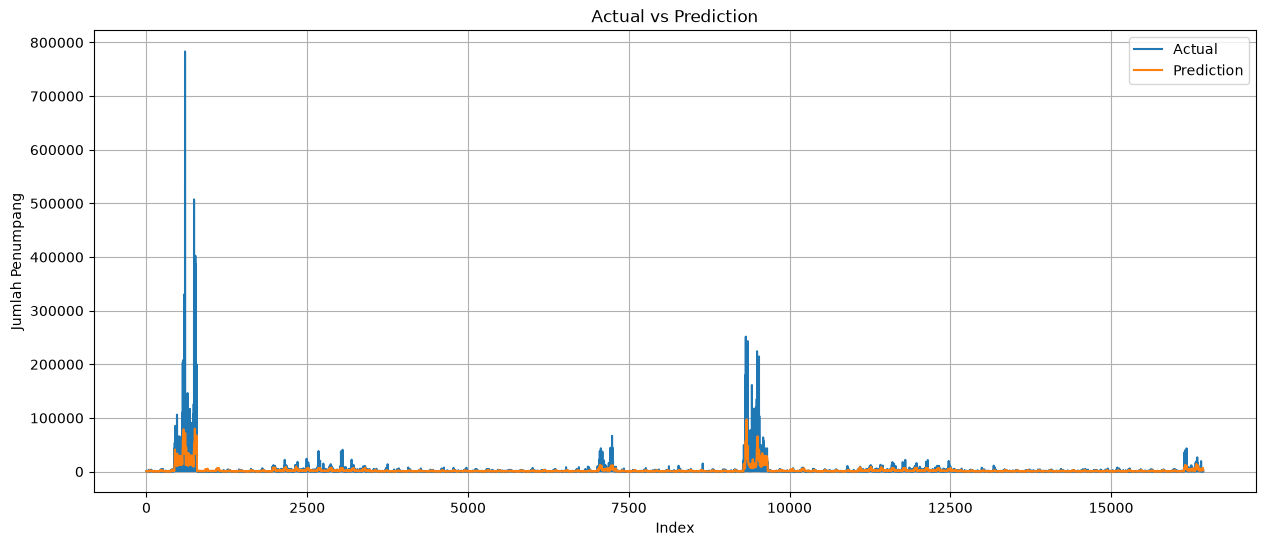

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Prediction"
)

plt.title("Actual vs Prediction")

plt.xlabel("Index")

plt.ylabel("Jumlah Penumpang")

plt.legend()

plt.grid(True)

plt.show()

In [28]:
importance = rf_model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance

,Feature,Importance
5,is_lebaran,0.337671
2,hari,0.167327
0,tahun,0.092828
3,hari_ke,0.090915
8,kapasitas_kursi,0.056201
9,gerbong_tersedia,0.054595
6,is_libur_sekolah,0.045797
4,is_weekend,0.040413
12,kereta_code,0.037593
1,bulan,0.024885


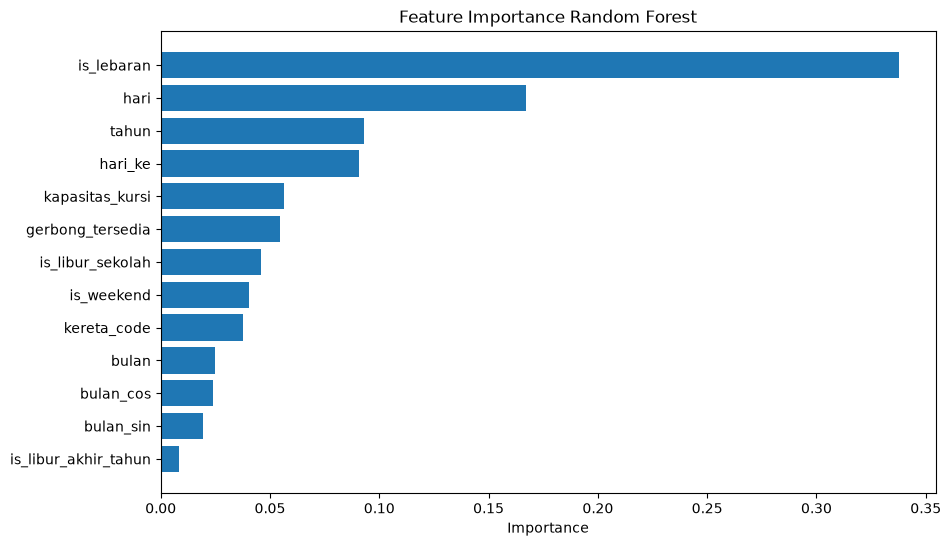

In [29]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Feature Importance Random Forest")

plt.show()

## Eksport Data

In [30]:
df.to_csv('data/cleaned_Data_Kereta.csv', index=False)

In [31]:
df = pd.read_csv('data/cleaned_Data_Kereta.csv')

Dahboard

In [32]:
import joblib

joblib.dump(rf_model, 'model/rf_model.joblib')
joblib.dump(kereta_map, 'model/kereta_map.joblib')

print("Model and train mapping saved successfully.")

Model and train mapping saved successfully.


In [33]:
import json

# 1. Simpan metrik evaluasi (MAE, RMSE, MAPE, R^2) dari data uji
eval_metrics = {
    "mae": float(mae),
    "rmse": float(rmse),
    "mape": float(mape),
    "r2": float(r2),
}
with open('output/eval_metrics.json', 'w') as f:
    json.dump(eval_metrics, f)

# 2. Simpan hasil Actual vs Prediction dari data uji
hasil[["Actual", "Prediction"]].to_csv(
    'output/eval_results.csv',
    index=False
)

# 3. Simpan feature importance
feature_importance.to_csv(
    'output/feature_importance.csv',
    index=False
)

print("3 file evaluasi berhasil disimpan di folder Dataset.")

3 file evaluasi berhasil disimpan di folder Dataset.


In [34]:
!pip install streamlit pyngrok joblib plotly pandas scikit-learn prophet -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import numpy as np
import pandas as pd

FEATURE_COLUMNS = [
    "tahun",
    "bulan",
    "hari",
    "hari_ke",
    "is_weekend",
    "is_lebaran",
    "is_libur_sekolah",
    "is_libur_akhir_tahun",
    "kapasitas_kursi",
    "gerbong_tersedia",
    "bulan_sin",
    "bulan_cos",
    "kereta_code",
]

HARI_INDO = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
BULAN_INDO = [
    "Januari", "Februari", "Maret", "April", "Mei", "Juni",
    "Juli", "Agustus", "September", "Oktober", "November", "Desember",
]

KURSI_PER_GERBONG = 80  # konsisten dengan asumsi pada notebook (gerbong_dibutuhkan = ceil(penumpang/80))


def nama_hari(tanggal):
    """Mengembalikan nama hari dalam Bahasa Indonesia dari objek date/datetime."""
    return HARI_INDO[tanggal.weekday()]


def format_tanggal_indo(tanggal):
    """Format tanggal menjadi 'D Bulan YYYY', contoh: 17 Agustus 2026."""
    return f"{tanggal.day} {BULAN_INDO[tanggal.month - 1]} {tanggal.year}"


def saran_kondisi_khusus(tanggal):
    """
    Memberi NILAI AWAL (default) untuk checkbox kondisi khusus berdasarkan
    aturan kalender akademik/libur yang umum berlaku di Indonesia.

    Ini hanya SARAN, bukan kebenaran mutlak, karena tanggal libur sekolah dan
    Lebaran berubah setiap tahun dan ditentukan lewat SKB Menteri/Kemenag.
    Pengguna tetap bisa mengubahnya secara manual di sidebar sebelum prediksi.
    """
    bulan, hari = tanggal.month, tanggal.day
    libur_akhir_tahun = (bulan == 12 and hari >= 20) or (bulan == 1 and hari <= 3)
    libur_sekolah = bulan in (6, 7) or (bulan == 12 and hari >= 18)
    return {
        "is_libur_akhir_tahun": libur_akhir_tahun,
        "is_libur_sekolah": libur_sekolah,
        "is_lebaran": False,
    }


def get_info_kereta(df, nama_kereta):
    """
    Mengambil informasi statis & historis satu kereta dari dataset bersih:
    kapasitas kursi, jumlah gerbong tersedia (nilai paling umum/modus),
    rata-rata historis, nilai maksimum historis, dan rentang periode data.
    """
    subset = df[df["nama_kereta"] == nama_kereta]
    if subset.empty:
        return None

    return {
        "kapasitas_kursi": int(subset["kapasitas_kursi"].mode().iloc[0]),
        "gerbong_tersedia": int(subset["gerbong_tersedia"].mode().iloc[0]),
        "rata_rata_historis": float(subset["jumlah_penumpang"].mean()),
        "maksimum_historis": float(subset["jumlah_penumpang"].max()),
        "jumlah_data": int(len(subset)),
        "periode_awal": subset["tanggal"].min(),
        "periode_akhir": subset["tanggal"].max(),
    }


def bangun_fitur(tanggal, kereta_code, kapasitas_kursi, gerbong_tersedia,
                  is_lebaran, is_libur_sekolah, is_libur_akhir_tahun):
    """
    Membangun satu baris DataFrame fitur sesuai FEATURE_COLUMNS, siap
    dimasukkan ke rf_model.predict().
    """
    hari_ke = tanggal.weekday()
    bulan = tanggal.month

    baris = {
        "tahun": tanggal.year,
        "bulan": bulan,
        "hari": tanggal.day,
        "hari_ke": hari_ke,
        "is_weekend": int(hari_ke in (5, 6)),
        "is_lebaran": int(is_lebaran),
        "is_libur_sekolah": int(is_libur_sekolah),
        "is_libur_akhir_tahun": int(is_libur_akhir_tahun),
        "kapasitas_kursi": kapasitas_kursi,
        "gerbong_tersedia": gerbong_tersedia,
        "bulan_sin": np.sin(2 * np.pi * bulan / 12),
        "bulan_cos": np.cos(2 * np.pi * bulan / 12),
        "kereta_code": kereta_code,
    }
    return pd.DataFrame([baris], columns=FEATURE_COLUMNS)


def hitung_gerbong(prediksi_penumpang, gerbong_tersedia, kursi_per_gerbong=KURSI_PER_GERBONG):
    """Menghitung jumlah gerbong yang dibutuhkan dan kekurangannya (jika ada)."""
    gerbong_dibutuhkan = int(np.ceil(prediksi_penumpang / kursi_per_gerbong))
    tambahan_gerbong = max(0, gerbong_dibutuhkan - gerbong_tersedia)
    return gerbong_dibutuhkan, tambahan_gerbong


def klasifikasi_kepadatan(load_factor):
    """
    Mengklasifikasikan tingkat kepadatan berdasarkan load factor (%).
    Mengembalikan (label, kode_warna) dengan kode_warna salah satu dari
    'success', 'warning', 'danger' yang dipetakan ke CSS di app.py.
    """
    if load_factor < 70:
        return "Normal", "success"
    elif load_factor < 90:
        return "Padat", "warning"
    return "Sangat Padat", "danger"


def buat_rekomendasi(load_factor, tambahan_gerbong, is_lebaran, is_libur_sekolah, is_libur_akhir_tahun):
    """Menyusun daftar kartu rekomendasi tindakan berbasis aturan (rule-based)."""
    rekomendasi = []

    if load_factor < 70:
        rekomendasi.append({
            "icon": "✅",
            "judul": "Kapasitas Mencukupi",
            "isi": "Prediksi jumlah penumpang masih di bawah kapasitas kursi yang tersedia. "
                   "Operasional dapat berjalan dengan skema rangkaian normal tanpa penambahan armada.",
            "level": "success",
        })
    elif load_factor < 90:
        rekomendasi.append({
            "icon": "⚠️",
            "judul": "Perlu Antisipasi",
            "isi": "Tingkat kepadatan diprediksi cukup tinggi. Disarankan menyiapkan petugas tambahan "
                   "di stasiun keberangkatan dan memantau perkembangan penjualan tiket secara berkala.",
            "level": "warning",
        })
    else:
        rekomendasi.append({
            "icon": "🚨",
            "judul": "Risiko Kepadatan Tinggi",
            "isi": "Prediksi penumpang mendekati atau melampaui kapasitas kursi yang tersedia. "
                   "Disarankan berkoordinasi untuk penambahan rangkaian gerbong dan menyiapkan "
                   "skema pembatasan penjualan tiket di loket maupun aplikasi.",
            "level": "danger",
        })

    if tambahan_gerbong > 0:
        rekomendasi.append({
            "icon": "🚃",
            "judul": "Tambahan Gerbong Disarankan",
            "isi": f"Dengan asumsi kapasitas {KURSI_PER_GERBONG} kursi per gerbong, dibutuhkan kurang "
                   f"lebih {tambahan_gerbong} gerbong tambahan dari jumlah yang saat ini tersedia.",
            "level": "warning",
        })

    if is_lebaran:
        rekomendasi.append({
            "icon": "🕌",
            "judul": "Periode Mudik Lebaran",
            "isi": "Tanggal ini termasuk periode Lebaran. Data historis menunjukkan lonjakan penumpang "
                   "yang signifikan pada periode ini, sehingga koordinasi lintas unit perlu dilakukan "
                   "lebih awal dari biasanya.",
            "level": "info",
        })

    if is_libur_akhir_tahun:
        rekomendasi.append({
            "icon": "🎄",
            "judul": "Periode Libur Akhir Tahun",
            "isi": "Tanggal ini termasuk periode libur akhir tahun yang secara historis memiliki volume "
                   "penumpang lebih tinggi dibandingkan hari biasa.",
            "level": "info",
        })

    if is_libur_sekolah:
        rekomendasi.append({
            "icon": "🎒",
            "judul": "Periode Libur Sekolah",
            "isi": "Tanggal ini termasuk periode libur sekolah, yang umumnya turut mendorong "
                   "peningkatan jumlah penumpang dibandingkan hari sekolah biasa.",
            "level": "info",
        })

    return rekomendasi


def cek_ekstrapolasi(tanggal, tahun_min, tahun_maks):
    """
    Mengecek apakah tahun yang diprediksi berada di luar rentang tahun data latih.
    RandomForestRegressor adalah model berbasis pohon yang tidak mampu melakukan
    ekstrapolasi tren di luar rentang nilai yang pernah dipelajari, sehingga
    pengguna perlu diberi tahu jika memprediksi tahun yang jauh di luar data historis.
    """
    return tanggal.year > tahun_maks or tanggal.year < tahun_min

In [36]:
%%writefile app.py
import json
from datetime import date

import joblib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import streamlit as st

# ──────────────────────────────────────────────────────────────────────────
# KONFIGURASI HALAMAN & LOKASI FILE
# ──────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Dashboard Prediksi Penumpang KAI",
    page_icon="🚆",
    layout="wide",
    initial_sidebar_state="expanded",
)

MODEL_PATH = "model/rf_model.joblib"
KERETA_MAP_PATH = "model/kereta_map.joblib"

DATA_PATH = "data/cleaned_Data_Kereta.csv"

EVAL_METRICS_PATH = "output/eval_metrics.json"
EVAL_RESULTS_PATH = "output/eval_results.csv"
FEATURE_IMPORTANCE_PATH = "output/feature_importance.csv"

LABEL_FITUR = {
    "tahun": "Tahun",
    "bulan": "Bulan",
    "hari": "Tanggal (1-31)",
    "hari_ke": "Hari ke- dalam Minggu",
    "is_weekend": "Akhir Pekan",
    "is_lebaran": "Periode Lebaran",
    "is_libur_sekolah": "Libur Sekolah",
    "is_libur_akhir_tahun": "Libur Akhir Tahun",
    "kapasitas_kursi": "Kapasitas Kursi",
    "gerbong_tersedia": "Gerbong Tersedia",
    "bulan_sin": "Pola Musiman (Komponen Sin)",
    "bulan_cos": "Pola Musiman (Komponen Cos)",
    "kereta_code": "Jenis/Nama Kereta",
}

# Define KAI brand colors for consistent use in Python/Plotly
KAI_BLUE_900 = "#06335c"
KAI_BLUE_700 = "#0a5599"
KAI_BLUE_500 = "#1f7bc4"
KAI_ORANGE_700 = "#c2480a"
KAI_ORANGE_600 = "#e8650f"
TEXT_PRIMARY = "#ffffff" # Changed to white for visibility
TEXT_SECONDARY = "#f3f7fc" # Changed to lighter grey

# ──────────────────────────────────────────────────────────────────────────
# CSS — TEMA WARNA KAI (BIRU, ORANYE, PUTIH) DENGAN KONTRAS YANG TERJAGA
# ──────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
:root{
    --kai-blue-900:#06335c; --kai-blue-700:#0a5599; --kai-blue-500:#1f7bc4; --kai-blue-100:#e8f1fa;
    --kai-orange-600:#e8650f; --kai-orange-700:#c2480a; --kai-orange-100:#fdeadb;
    --bg-page:#f4f6fa; --bg-card:#ffffff;
    --text-primary:#1e293b; --text-secondary:#64748b; --border-soft:#e6eaf0;
    --success-bg:#e7f6ec; --success-text:#0f6e37;
    --warning-bg:#fff2e0; --warning-text:#9c4d04;
    --danger-bg:#fdeaea;  --danger-text:#c0392b;
    --info-bg:#e8f1fa;    --info-text:#0a5599;
}

.stApp { background-color: var(--bg-page); }
.block-container { padding-top: 1.6rem; max-width: 1180px; }
h1,h2,h3,h4 { color: var(--text-primary); }
p, span, label, div { color: var(--text-primary); }

/* ---------- SIDEBAR ---------- */
[data-testid="stSidebar"]{
    background: linear-gradient(180deg, var(--kai-blue-900) 0%, var(--kai-blue-700) 100%);
}
[data-testid="stSidebar"] [data-testid="stWidgetLabel"] p,
[data-testid="stSidebar"] .stMarkdown p,
[data-testid="stSidebar"] .stMarkdown h1,
[data-testid="stSidebar"] .stMarkdown h2,
[data-testid="stSidebar"] .stMarkdown h3,
[data-testid="stSidebar"] .stCaption {
    color: #f3f7fc !important;
}
[data-testid="stSidebar"] [data-testid="stExpander"]{
    background: rgba(255,255,255,0.06);
    border: 1px solid rgba(255,255,255,0.18);
    border-radius: 10px;
}
[data-testid="stSidebar"] [data-testid="stExpander"] summary p { color:#f3f7fc !important; }
[data-testid="stSidebar"] hr { border-color: rgba(255,255,255,0.2); }

.sidebar-brand{ padding: 4px 0 18px 0; }
.sidebar-brand .brand-title{ font-size:1.5rem; font-weight:800; color:#ffffff; margin:0; line-height:1.15; }
.sidebar-brand .brand-sub{ font-size:0.85rem; color:#cfe2f5; margin-top:4px; }
.sidebar-foot{ font-size:0.74rem; color:#bcd2e8; line-height:1.5; margin-top:10px; }

/* ---------- BUTTON UTAMA (ORANYE KAI) ---------- */
.stButton > button{
    background-color: var(--kai-orange-700);
    color:#ffffff;
    border:none;
    border-radius:10px;
    font-weight:700;
    padding:0.6rem 1rem;
    transition: filter 0.15s ease;
}
.stButton > button:hover{ filter: brightness(1.08); color:#ffffff; }
.stButton > button p { color:#ffffff !important; }

/* ---------- KARTU ---------- */
.kai-card{
    background: var(--bg-card);
    border: 1px solid var(--border-soft);
    border-radius: 16px;
    padding: 22px 24px;
    box-shadow: 0 2px 10px rgba(6,51,92,0.05);
    margin-bottom: 18px;
}
.kai-card-accent{ border-left: 4_px solid var(--kai-orange-600); }

/* ---------- HEADER SEKSI: aksen garis mirip rel kereta ---------- */
.kai-section-head{ display:flex; align-items:center; gap:10px; margin: 6px 0 14px 0; }
.kai-section-head .icon-badge{
    width:34px; height:34px; border-radius:9px; background:var(--kai-blue-100);
    display:flex; align-items:center; justify-content:center; font-size:1.05rem;
}
.kai-section-head h3{ margin:0; color:var(--kai-blue-900); font-size:1.18rem; }
.kai-section-head .kai-sub{ color:var(--text-secondary); font-size:0.85rem; margin:2px 0 0 44px; }

.rail-divider{
    height:10px; margin: 28px 0 22px 0; border-radius:6px;
    background-image: repeating-linear-gradient(90deg, var(--border-soft) 0 14px, transparent 14px 22px);
    background-position:center; background-repeat:repeat-x; background-size:auto 2px;
    border-top:2px solid var(--border-soft); border-bottom:2px solid var(--border-soft);
}

/* ---------- METRIC / INFO CHIP ---------- */
.metric-label{ font-size:0.78rem; color:var(--text-secondary); text-transform:uppercase; letter-spacing:0.04em; font-weight:600; }
.metric-value{ font-size:2.0rem; font-weight:800; color:var(--kai-blue-900); margin-top:2px; }
.metric-caption{ font-size:0.85rem; color:var(--text-secondary); margin-top:6px; }

.info-chip{
    background: var(--kai-blue-100); border-radius:12px; padding:12px 14px; height:100%;
}
.info-chip .info-chip-label{ font-size:0.74rem; color:var(--kai-blue-700); font-weight:700; text-transform:uppercase; letter-spacing:0.03em; }
.info-chip .info-chip-value{ font-size:1.15rem; color:var(--kai-blue-900); font-weight:700; margin-top:3px; }

/* ---------- BADGE STATUS ---------- */
.kai-badge{ display:inline-block; padding:5px 13px; border-radius:999px; font-size:0.82rem; font-weight:700; }
.badge-success{ background:var(--success-bg); color:var(--success-text); }
.badge-warning{ background:var(--warning-bg); color:var(--warning-text); }
.badge-danger { background:var(--danger-bg);  color:var(--danger-text); }
.badge-info   { background:var(--info-bg);    color:var(--info-text); }

/* ---------- PROGRESS BAR KAPASITAS ---------- */
.cap-track{ background:#eef1f5; border-radius:999px; height:14px; width:100%; overflow:hidden; }
.cap-fill{ height:100%; border-radius:999px; }

/* ---------- KARTU REKOMENDASI ---------- */
.rec-card{ background:#ffffff; border:1px solid var(--border-soft); border-radius:14px; padding:16px 18px; height:100%; }
.rec-card h4{ margin:0 0 6px 0; font-size:1.0rem; color:var(--text-primary); }
.rec-card p{ font-size:0.88rem; color:var(--text-secondary); margin:0; line-height:1.5; }
.rec-card .rec-strip{ height:4px; border-radius:4px; margin-bottom:12px; width:46px; }
.strip-success{ background:var(--success-text); }
.strip-warning{ background:var(--warning-text); }
.strip-danger{ background:var(--danger-text); }
.strip-info{ background:var(--info-text); }

/* ---------- LANDING (BELUM PREDIKSI) ---------- */
.kai-landing{
    background: linear-gradient(135deg, var(--kai-blue-900), var(--kai-blue-700));
    border-radius:18px; padding:34px 32px; color:#ffffff; margin-bottom:18px;
}
.kai-landing h2{ color:#ffffff; margin:0 0 6px 0; }
.kai-landing p{ color:#dceaf7; margin:0; font-size:0.95rem; max-width:640px; }
/* --- CSS Update untuk Kalender & Widget --- */

/* --- CSS Update untuk Kalender (Warna Putih Agar Terlihat Jelas) --- */

/* Menargetkan angka tanggal agar menjadi putih */
div[data-baseweb="calendar"] div[role="gridcell"] button div,
div[data-baseweb="calendar"] div[role="gridcell"] button {
    color: #ffffff !important;
}

/* Menargetkan hari (Su, Mo, Tu, dst) di header kalender agar putih */
div[data-baseweb="calendar"] div[role="columnheader"] {
    color: #ffffff !important;
}

/* Menargetkan teks bulan dan tahun di header agar putih */
div[data-baseweb="calendar"] [data-testid="stText"],
div[data-baseweb="calendar"] div[role="presentation"] {
    color: #ffffff !important;
}

/* Menargetkan angka tanggal yang di luar bulan (disabled) agar abu-abu terang */
div[data-baseweb="calendar"] div[role="gridcell"] button:disabled div {
    color: #888888 !important;
}
</style>
""", unsafe_allow_html=True)

# ──────────────────────────────────────────────────────────────────────────
# FUNGSI BANTUAN UNTUK DASHBOARD (DIPINDAH DARI UTILS/FUNCTIONS.PY)
# ──────────────────────────────────────────────────────────────────────────
FEATURE_COLUMNS = [
    "tahun",
    "bulan",
    "hari",
    "hari_ke",
    "is_weekend",
    "is_lebaran",
    "is_libur_sekolah",
    "is_libur_akhir_tahun",
    "kapasitas_kursi",
    "gerbong_tersedia",
    "bulan_sin",
    "bulan_cos",
    "kereta_code",
]

HARI_INDO = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
BULAN_INDO = [
    "Januari", "Februari", "Maret", "April", "Mei", "Juni",
    "Juli", "Agustus", "September", "Oktober", "November", "Desember",
]

KURSI_PER_GERBONG = 80  # konsisten dengan asumsi pada notebook (gerbong_dibutuhkan = ceil(penumpang/80))

def nama_hari(tanggal):
    """Mengembalikan nama hari dalam Bahasa Indonesia dari objek date/datetime."""
    return HARI_INDO[tanggal.weekday()]


def format_tanggal_indo(tanggal):
    """Format tanggal menjadi 'D Bulan YYYY', contoh: 17 Agustus 2026."""
    return f"{tanggal.day} {BULAN_INDO[tanggal.month - 1]} {tanggal.year}"


def saran_kondisi_khusus(tanggal):
    """
    Memberi NILAI AWAL (default) untuk checkbox kondisi khusus berdasarkan
    aturan kalender akademik/libur yang umum berlaku di Indonesia.

    Ini hanya SARAN, bukan kebenaran mutlak, karena tanggal libur sekolah dan
    Lebaran berubah setiap tahun dan ditentukan lewat SKB Menteri/Kemenag.
    Pengguna tetap bisa mengubahnya secara manual di sidebar sebelum prediksi.
    """
    bulan, hari = tanggal.month, tanggal.day
    libur_akhir_tahun = (bulan == 12 and hari >= 20) or (bulan == 1 and hari <= 3)
    libur_sekolah = bulan in (6, 7) or (bulan == 12 and hari >= 18)
    return {
        "is_libur_akhir_tahun": libur_akhir_tahun,
        "is_libur_sekolah": libur_sekolah,
        "is_lebaran": False,
    }


def get_info_kereta(df, nama_kereta):
    """
    Mengambil informasi statis & historis satu kereta dari dataset bersih:
    kapasitas kursi, jumlah gerbong tersedia (nilai paling umum/modus),
    rata-rata historis, nilai maksimum historis, dan rentang periode data.
    """
    subset = df[df["nama_kereta"] == nama_kereta]
    if subset.empty:
        return None

    return {
        "kapasitas_kursi": int(subset["kapasitas_kursi"].mode().iloc[0]),
        "gerbong_tersedia": int(subset["gerbong_tersedia"].mode().iloc[0]),
        "rata_rata_historis": float(subset["jumlah_penumpang"].mean()),
        "maksimum_historis": float(subset["jumlah_penumpang"].max()),
        "jumlah_data": int(len(subset)),
        "periode_awal": subset["tanggal"].min(),
        "periode_akhir": subset["tanggal"].max(),
    }


def bangun_fitur(tanggal, kereta_code, kapasitas_kursi, gerbong_tersedia,
                  is_lebaran, is_libur_sekolah, is_libur_akhir_tahun):
    """
    Membangun satu baris DataFrame fitur sesuai FEATURE_COLUMNS, siap
    dimasukkan ke rf_model.predict().
    """
    hari_ke = tanggal.weekday()
    bulan = tanggal.month

    baris = {
        "tahun": tanggal.year,
        "bulan": bulan,
        "hari": tanggal.day,
        "hari_ke": hari_ke,
        "is_weekend": int(hari_ke in (5, 6)),
        "is_lebaran": int(is_lebaran),
        "is_libur_sekolah": int(is_libur_sekolah),
        "is_libur_akhir_tahun": int(is_libur_akhir_tahun),
        "kapasitas_kursi": kapasitas_kursi,
        "gerbong_tersedia": gerbong_tersedia,
        "bulan_sin": np.sin(2 * np.pi * bulan / 12),
        "bulan_cos": np.cos(2 * np.pi * bulan / 12),
        "kereta_code": kereta_code,
    }
    return pd.DataFrame([baris], columns=FEATURE_COLUMNS)


def hitung_gerbong(prediksi_penumpang, gerbong_tersedia, kursi_per_gerbong=KURSI_PER_GERBONG):
    """Menghitung jumlah gerbong yang dibutuhkan dan kekurangannya (jika ada)."""
    gerbong_dibutuhkan = int(np.ceil(prediksi_penumpang / kursi_per_gerbong))
    tambahan_gerbong = max(0, gerbong_dibutuhkan - gerbong_tersedia)
    return gerbong_dibutuhkan, tambahan_gerbong


def klasifikasi_kepadatan(load_factor):
    """
    Mengklasifikasikan tingkat kepadatan berdasarkan load factor (%).
    Mengembalikan (label, kode_warna) dengan kode_warna salah satu dari
    'success', 'warning', 'danger' yang dipetakan ke CSS di app.py.
    """
    if load_factor < 70:
        return "Normal", "success"
    elif load_factor < 90:
        return "Padat", "warning"
    return "Sangat Padat", "danger"


def buat_rekomendasi(load_factor, tambahan_gerbong, is_lebaran, is_libur_sekolah, is_libur_akhir_tahun):
    """Menyusun daftar kartu rekomendasi tindakan berbasis aturan (rule-based)."""
    rekomendasi = []

    if load_factor < 70:
        rekomendasi.append({
            "icon": "✅",
            "judul": "Kapasitas Mencukupi",
            "isi": "Prediksi jumlah penumpang masih di bawah kapasitas kursi yang tersedia. "
                   "Operasional dapat berjalan dengan skema rangkaian normal tanpa penambahan armada.",
            "level": "success",
        })
    elif load_factor < 90:
        rekomendasi.append({
            "icon": "⚠️",
            "judul": "Perlu Antisipasi",
            "isi": "Tingkat kepadatan diprediksi cukup tinggi. Disarankan menyiapkan petugas tambahan "
                   "di stasiun keberangkatan dan memantau perkembangan penjualan tiket secara berkala.",
            "level": "warning",
        })
    else:
        rekomendasi.append({
            "icon": "🚨",
            "judul": "Risiko Kepadatan Tinggi",
            "isi": "Prediksi penumpang mendekati atau melampaui kapasitas kursi yang tersedia. "
                   "Disarankan berkoordinasi untuk penambahan rangkaian gerbong dan menyiapkan "
                   "skema pembatasan penjualan tiket di loket maupun aplikasi.",
            "level": "danger",
        })

    if tambahan_gerbong > 0:
        rekomendasi.append({
            "icon": "🚃",
            "judul": "Tambahan Gerbong Disarankan",
            "isi": f"Dengan asumsi kapasitas {KURSI_PER_GERBONG} kursi per gerbong, dibutuhkan kurang "
                   f"lebih {tambahan_gerbong} gerbong tambahan dari jumlah yang saat ini tersedia.",
            "level": "warning",
        })

    if is_lebaran:
        rekomendasi.append({
            "icon": "🕌",
            "judul": "Periode Mudik Lebaran",
            "isi": "Tanggal ini termasuk periode Lebaran. Data historis menunjukkan lonjakan penumpang "
                   "yang signifikan pada periode ini, sehingga koordinasi lintas unit perlu dilakukan "
                   "lebih awal dari biasanya.",
            "level": "info",
        })

    if is_libur_akhir_tahun:
        rekomendasi.append({
            "icon": "🎄",
            "judul": "Periode Libur Akhir Tahun",
            "isi": "Tanggal ini termasuk periode libur akhir tahun yang secara historis memiliki volume "
                   "penumpang lebih tinggi dibandingkan hari biasa.",
            "level": "info",
        })

    if is_libur_sekolah:
        rekomendasi.append({
            "icon": "🎒",
            "judul": "Periode Libur Sekolah",
            "isi": "Tanggal ini termasuk periode libur sekolah, yang umumnya turut mendorong "
                   "peningkatan jumlah penumpang dibandingkan hari sekolah biasa.",
            "level": "info",
        })

    return rekomendasi


def cek_ekstrapolasi(tanggal, tahun_min, tahun_maks):
    """
    Mengecek apakah tahun yang diprediksi berada di luar rentang tahun data latih.
    RandomForestRegressor adalah model berbasis pohon yang tidak mampu melakukan
    ekstrapolasi tren di luar rentang nilai yang pernah dipelajari, sehingga
    pengguna perlu diberi tahu jika memprediksi tahun yang jauh di luar data historis.
    """
    return tanggal.year > tahun_maks or tanggal.year < tahun_min


# ──────────────────────────────────────────────────────────────────────────
# PEMUATAN ARTEFAK (MODEL, DATA, HASIL EVALUASI) — DI-CACHE AGAR CEPAT
# ──────────────────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner="Memuat model Random Forest...")
def load_model():
    return joblib.load(MODEL_PATH)


@st.cache_resource(show_spinner=False)
def load_kereta_map():
    return joblib.load(KERETA_MAP_PATH)


@st.cache_data(show_spinner="Memuat dataset historis...")
def load_dataset():
    df = pd.read_csv(DATA_PATH)
    df["tanggal"] = pd.to_datetime(df["tanggal"])
    return df


@st.cache_data(show_spinner=False)
def load_eval_metrics():
    with open(EVAL_METRICS_PATH) as f:
        return json.load(f)


@st.cache_data(show_spinner=False)
def load_eval_results():
    return pd.read_csv(EVAL_RESULTS_PATH)


@st.cache_data(show_spinner=False)
def load_feature_importance():
    return pd.read_csv(FEATURE_IMPORTANCE_PATH)

try:
    rf_model = load_model()
    kereta_map = load_kereta_map()
    df = load_dataset()
    eval_metrics = load_eval_metrics()
    eval_results = load_eval_results()
    feature_importance = load_feature_importance()
except FileNotFoundError as e:
    st.error(
        "Salah satu file artefak belum ditemukan: **{}**.\n\n"
        "Pastikan rf_model.joblib, kereta_map.joblib, cleaned_Data_Kereta.csv, "
        "eval_metrics.json, eval_results.csv, dan feature_importance.csv berada "
        "di folder yang sama dengan app.py.".format(e.filename)
    )
    st.stop()

kode_kereta_map = {nama: kode for kode, nama in kereta_map.items()}
daftar_kereta = sorted(kode_kereta_map.keys())
tahun_min, tahun_maks = int(df["tahun"].min()), int(df["tahun"].max())


# ──────────────────────────────────────────────────────────────────────────
# FUNGSI BANTUAN UNTUK RENDER KOMPONEN (HTML KECIL, DIPAKAI BERULANG)
# ──────────────────────────────────────────────────────────────────────────
def section_head(icon, title, subtitle=None):
    st.markdown(f"""
    <div class="kai-section-head">
        <div class="icon-badge">{icon}</div>
        <h3>{title}</h3>
    </div>
    {f'<div class="kai-sub">{subtitle}</div>' if subtitle else ''}
    """, unsafe_allow_html=True)


def info_chip(label, value):
    st.markdown(f"""
    <div class="info-chip">
        <div class="info-chip-label">{label}</div>
        <div class="info-chip-value">{value}</div>
    </div>
    """, unsafe_allow_html=True)


def badge(text, level):
    return f'<span class="kai-badge badge-{level}">{text}</span>'


def metric_card(label, value, caption=None, value_color=None):
    color_style = f"color:{value_color};" if value_color else ""
    st.markdown(f"""
    <div class="kai-card">
        <div class="metric-label">{label}</div>
        <div class="metric-value" style="{color_style}">{value}</div>
        {f'<div class="metric-caption">{caption}</div>' if caption else ''}
    </div>
    """, unsafe_allow_html=True)


def recommendation_card(icon, judul, isi, level):
    st.markdown(f"""
    <div class="rec-card">
        <div class="rec-strip strip-{level}"></div>
        <h4>{icon} {judul}</h4>
        <p>{isi}</p>
    </div>
    """, unsafe_allow_html=True)


def styled_fig(fig, height=380):
    fig.update_layout(
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        # Mengatur warna font dasar menjadi hitam untuk label dan angka
        font=dict(color="#000000", size=13),
        margin=dict(l=10, r=10, t=50, b=10),
        height=height,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        hoverlabel=dict(bgcolor="white", font_size=12),
        # Mengatur warna judul agar hitam
        title=dict(font=dict(color="#000000", size=16)),
    )

    # Memperjelas warna sumbu X dan Y agar teks label menjadi hitam
    fig.update_xaxes(
        showgrid=True, zeroline=False,
        linecolor="#000000", gridcolor="#cbd5e1",
        title_font=dict(color="#000000"), # Hitam untuk "Indeks Data Uji" / "Tingkat Kepentingan"
        tickfont=dict(color="#000000")    # Hitam untuk angka sumbu
    )
    fig.update_yaxes(
        showgrid=True, zeroline=False,
        linecolor="#000000", gridcolor="#cbd5e1",
        title_font=dict(color="#000000"), # Hitam untuk "Jumlah Penumpang"
        tickfont=dict(color="#000000")    # Hitam untuk angka sumbu
    )
    return fig


# ──────────────────────────────────────────────────────────────────────────
# SIDEBAR — INPUT PARAMETER PREDIKSI
# ──────────────────────────────────────────────────────────────────────────
if "hasil_prediksi" not in st.session_state:
    st.session_state.hasil_prediksi = None

with st.sidebar:
    st.markdown("""
    <div class="sidebar-brand">
        <p class="brand-title">🚆 KAI Predict</p>
        <p class="brand-sub">Dashboard Prediksi Penumpang Harian</p>
    </div>
    """, unsafe_allow_html=True)
    st.markdown("<hr/>", unsafe_allow_html=True)

    st.markdown("**Parameter Prediksi**")
    tanggal_input = st.date_input(
        "Tanggal Keberangkatan",
        value=date.today(),
        help="Pilih tanggal yang ingin diprediksi jumlah penumpangnya.",
    )
    nama_kereta_input = st.selectbox(
        "Nama Kereta",
        options=daftar_kereta,
        help="Pilih kereta yang ingin diprediksi.",
    )

    # Catatan teknis: checkbox dengan parameter key hanya membaca value= pada
    # render PERTAMA kali. Supaya saran kondisi khusus ikut berubah setiap
    # tanggal diganti, session_state untuk ketiga checkbox di-refresh secara
    # manual SEBELUM widget dibuat, setiap kali tanggal_input berbeda dari
    # tanggal pada rerun sebelumnya.
    if st.session_state.get("tanggal_sebelumnya") != tanggal_input:
        saran = saran_kondisi_khusus(tanggal_input)
        st.session_state["chk_lebaran"] = saran["is_lebaran"]
        st.session_state["chk_sekolah"] = saran["is_libur_sekolah"]
        st.session_state["chk_akhirtahun"] = saran["is_libur_akhir_tahun"]
        st.session_state["tanggal_sebelumnya"] = tanggal_input

    with st.expander("⚙️ Kondisi Khusus (Opsional)"):
        st.caption("Sesuaikan dengan kalender resmi bila perlu. Nilai di bawah hanya saran awal.")
        is_lebaran = st.checkbox("Periode Lebaran", key="chk_lebaran")
        is_libur_sekolah = st.checkbox("Libur Sekolah", key="chk_sekolah")
        is_libur_akhir_tahun = st.checkbox("Libur Akhir Tahun", key="chk_akhirtahun")

    tombol_prediksi = st.button("🔍 Jalankan Prediksi", width="stretch")

    st.markdown(f"""
    <div class="sidebar-foot">
        Model: Random Forest Regressor<br/>
        Periode data latih: {tahun_min}–{tahun_maks}<br/>
        Total kereta tercatat: {len(daftar_kereta)}
    </div>
    """, unsafe_allow_html=True)


# ──────────────────────────────────────────────────────────────────────────
# PROSES PREDIKSI SAAT TOMBOL DIKLIK
# ──────────────────────────────────────────────────────────────────────────
if tombol_prediksi:
    info_kereta = get_info_kereta(df, nama_kereta_input)

    fitur = bangun_fitur(
        tanggal=tanggal_input,
        kereta_code=kode_kereta_map[nama_kereta_input],
        kapasitas_kursi=info_kereta["kapasitas_kursi"],
        gerbong_tersedia=info_kereta["gerbong_tersedia"],
        is_lebaran=is_lebaran,
        is_libur_sekolah=is_libur_sekolah,
        is_libur_akhir_tahun=is_libur_akhir_tahun,
    )
    prediksi = float(rf_model.predict(fitur)[0])
    prediksi = max(0, prediksi)

    load_factor = (prediksi / info_kereta["kapasitas_kursi"]) * 100
    label_kepadatan, level_kepadatan = klasifikasi_kepadatan(load_factor)
    gerbong_dibutuhkan, tambahan_gerbong = hitung_gerbong(prediksi, info_kereta["gerbong_tersedia"])
    rekomendasi_list = buat_rekomendasi(
        load_factor, tambahan_gerbong, is_lebaran, is_libur_sekolah, is_libur_akhir_tahun
    )

    # Cek apakah ada data aktual pada tanggal & kereta yang sama (untuk validasi, bukan acuan)
    cocok = df[(df["nama_kereta"] == nama_kereta_input) & (df["tanggal"].dt.date == tanggal_input)]
    aktual = float(cocok["jumlah_penumpang"].iloc[0]) if not cocok.empty else None

    st.session_state.hasil_prediksi = {
        "nama_kereta": nama_kereta_input,
        "tanggal": tanggal_input,
        "info_kereta": info_kereta,
        "is_lebaran": is_lebaran,
        "is_libur_sekolah": is_libur_sekolah,
        "is_libur_akhir_tahun": is_libur_akhir_tahun,
        "prediksi": prediksi,
        "load_factor": load_factor,
        "label_kepadatan": label_kepadatan,
        "level_kepadatan": level_kepadatan,
        "gerbong_dibutuhkan": gerbong_dibutuhkan,
        "tambahan_gerbong": tambahan_gerbong,
        "rekomendasi_list": rekomendasi_list,
        "aktual": aktual,
        "ekstrapolasi": cek_ekstrapolasi(tanggal_input, tahun_min, tahun_maks),
    }


# ──────────────────────────────────────────────────────────────────────────
# HEADER UTAMA (SELALU TAMPIL)
# ──────────────────────────────────────────────────────────────────────────
st.markdown("""
<h1 style="margin-bottom:2px;">🚆 Dashboard Prediksi Penumpang Kereta Api</h1>
<p style="color:var(--text-secondary); margin-top:0;">
    Estimasi jumlah penumpang harian berbasis Random Forest Regressor untuk mendukung
    perencanaan kebutuhan gerbong dan kapasitas operasional.
</p>
""", unsafe_allow_html=True)

hasil = st.session_state.hasil_prediksi

# ──────────────────────────────────────────────────────────────────────────
# TAMPILAN AWAL (BELUM ADA PREDIKSI)
# ──────────────────────────────────────────────────────────────────────────
if hasil is None:
    st.markdown(f"""
    <div class="kai-landing">
        <h2>Pilih parameter di sidebar untuk mulai</h2>
        <p>Tentukan tanggal keberangkatan dan nama kereta pada panel sebelah kiri,
        lalu klik tombol <b>Jalankan Prediksi</b> untuk melihat estimasi jumlah
        penumpang, status kepadatan, dan rekomendasi operasional.</p>
    </div>
    """, unsafe_allow_html=True)

    c1, c2, c3 = st.columns(3)
    with c1:
        info_chip("Total Kereta Tercatat", f"{len(daftar_kereta)} kereta")
    with c2:
        info_chip("Periode Data Historis", f"{tahun_min}–{tahun_maks}")
    with c3:
        info_chip("Total Data Historis", f"{len(df):,} baris")

# ──────────────────────────────────────────────────────────────────────────
# HASIL PREDIKSI: 1) INFO UMUM -> 2) PREDIKSI & REKOMENDASI -> 3) EVALUASI
# ──────────────────────────────────────────────────────────────────────────
else:
    info_k = hasil["info_kereta"]
    tgl = hasil["tanggal"]

    # ===================== SEKSI 1 — INFORMASI UMUM =====================
    section_head("ℹ️", "Informasi Umum", "Ringkasan kereta dan tanggal yang dipilih")

    status_hari = "Akhir Pekan" if tgl.weekday() in (5, 6) else "Hari Kerja"
    badge_khusus = ""
    if hasil["is_lebaran"]:
        badge_khusus += badge("Periode Lebaran", "info") + " "
    if hasil["is_libur_sekolah"]:
        badge_khusus += badge("Libur Sekolah", "info") + " "
    if hasil["is_libur_akhir_tahun"]:
        badge_khusus += badge("Libur Akhir Tahun", "info") + " "

    st.markdown(f"""
    <div class="kai-card kai-card-accent">
        <div style="display:flex; justify-content:space-between; align-items:flex-start; flex-wrap:wrap; gap:14px;">
            <div>
                <div style="font-size:1.4rem; font-weight:800; color:{KAI_BLUE_900};">{hasil['nama_kereta']}</div>
                <div style="color:var(--text-secondary); margin-top:2px;">
                    {format_tanggal_indo(tgl)} &middot; {nama_hari(tgl)} &middot; {status_hari}
                </div>
            </div>
            <div style="text-align:right;">{badge_khusus if badge_khusus else badge("Hari Reguler", "info")}</div>
        </div>
    </div>
    """, unsafe_allow_html=True)

    c1, c2, c3, c4 = st.columns(4)
    with c1:
        info_chip("Kapasitas Kursi", f"{info_k['kapasitas_kursi']:,} kursi")
    with c2:
        info_chip("Gerbong Tersedia", f"{info_k['gerbong_tersedia']} gerbong")
    with c3:
        info_chip("Rata-rata Historis", f"{info_k['rata_rata_historis']:,.0f} pnp/hari")
    with c4:
        info_chip("Periode Data Kereta", f"{info_k['periode_awal'].year}–{info_k['periode_akhir'].year}")


    st.markdown('<div class="rail-divider"></div>', unsafe_allow_html=True)

    # ============== SEKSI 2 — HASIL PREDIKSI & REKOMENDASI ==============
    section_head("📈", "Hasil Prediksi & Rekomendasi", "Estimasi penumpang dan tindak lanjut yang disarankan")

    level_warna = {"success": "#0f6e37", "warning": "#9c4d04", "danger": "#c0392b"}[hasil["level_kepadatan"]]

    colA, colB = st.columns(2)
    with colA:
        caption_aktual = ""
        if hasil["aktual"] is not None:
            selisih = hasil["prediksi"] - hasil["aktual"]
            caption_aktual = (
                f"Data aktual tercatat: {hasil['aktual']:,.0f} penumpang "
                f"(selisih prediksi {selisih:+,.0f})"
            )
        metric_card(
            "Prediksi Jumlah Penumpang",
            f"{hasil['prediksi']:,.0f} <span style='font-size:1rem; font-weight:600;'>orang</span>",
            caption=caption_aktual if caption_aktual else f"Rata-rata historis: {info_k['rata_rata_historis']:,.0f} orang",
        )
    with colB:
        metric_card(
            "Tingkat Kepadatan (Load Factor)",
            f"{hasil['load_factor']:.1f}%",
            value_color=level_warna,
            caption=f"Status: {badge(hasil['label_kepadatan'], hasil['level_kepadatan'])}",
        )

    fill_pct = min(100, hasil["load_factor"])
    st.markdown(f"""
    <div class="kai-card">
        <div class="metric-label" style="margin-bottom:8px;">Pemakaian Kapasitas Kursi</div>
        <div class="cap-track"><div class="cap-fill" style="width:{fill_pct}%; background:{level_warna};"></div></div>
        <div style="display:flex; justify-content:space-between; margin-top:14px;">
            <div><span class="metric-label">Gerbong Tersedia</span><br/><b>{info_k['gerbong_tersedia']} gerbong</b></div>
            <div><span class="metric-label">Gerbong Dibutuhkan</span><br/><b>{hasil['gerbong_dibutuhkan']} gerbong</b></div>
            <div><span class="metric-label">Tambahan Diperlukan</span><br/>
                <b style="color:{'#c0392b' if hasil['tambahan_gerbong'] > 0 else '#0f6e37'};">
                    {hasil['tambahan_gerbong']} gerbong
                </b>
            </div>
        </div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("**💡 Rekomendasi Tindakan**")
    rek_cols = st.columns(len(hasil["rekomendasi_list"]))
    for col, r in zip(rek_cols, hasil["rekomendasi_list"]):
        with col:
            recommendation_card(r["icon"], r["judul"], r["isi"], r["level"])

    # Grafik pola musiman bulanan kereta terpilih, dengan titik prediksi
    df_kereta = df[df["nama_kereta"] == hasil["nama_kereta"]]
    pola_bulanan = df_kereta.groupby("bulan")["jumlah_penumpang"].mean().reindex(range(1, 13))

    fig_musiman = go.Figure()
    fig_musiman.add_trace(go.Scatter(
        x=BULAN_INDO, y=pola_bulanan.values,
        mode="lines+markers", name="Rata-rata Historis",
        line=dict(color=KAI_BLUE_700, width=3), # Use KAI_BLUE_700
        marker=dict(size=6, color=KAI_BLUE_700), # Use KAI_BLUE_700 for markers
    ))
    fig_musiman.add_trace(go.Scatter(
        x=[BULAN_INDO[tgl.month - 1]], y=[hasil["prediksi"]],
        mode="markers", name="Prediksi Saat Ini",
        marker=dict(size=15, color=KAI_ORANGE_700, symbol="star"), # Use KAI_ORANGE_700
    ))
    fig_musiman.update_layout(title="Pola Musiman Rata-rata Penumpang per Bulan vs Prediksi")
    st.plotly_chart(styled_fig(fig_musiman, height=360), width="stretch")

    st.markdown('<div class="rail-divider"></div>', unsafe_allow_html=True)

    # ================ SEKSI 3 — EVALUASI MODEL & VISUALISASI ================M
    section_head(
        "📊", "Evaluasi Model & Visualisasi",
        "Performa umum model pada data uji (test set) — bukan akurasi prediksi tanggal di atas",
    )

    m1, m2, m3, m4 = st.columns(4)
    with m1:
        info_chip("MAE", f"{eval_metrics['mae']:,.1f} pnp")
    with m2:
        info_chip("RMSE", f"{eval_metrics['rmse']:,.1f} pnp")
    with m3:
        info_chip("MAPE", f"{eval_metrics['mape']:.1f}%")
    with m4:
        info_chip("R² Score", f"{eval_metrics['r2']:.3f}")

    st.caption(
        "MAE dan RMSE menunjukkan rata-rata selisih antara prediksi dan nilai aktual dalam satuan "
        "jumlah penumpang (semakin kecil semakin baik). MAPE menunjukkan persentase kesalahan "
        "rata-rata, dan R² menunjukkan seberapa besar variasi data yang berhasil dijelaskan model "
        "(rentang 0 sampai 1, semakin mendekati 1 semakin baik)."
    )

    colC, colD = st.columns(2)
    with colC:
        n_tampil = min(120, len(eval_results))
        subset_eval = eval_results.tail(n_tampil).reset_index(drop=True)
        fig_eval = go.Figure()
        fig_eval.add_trace(go.Scatter(
            y=subset_eval["Actual"], mode="lines", name="Aktual",
            line=dict(color=KAI_BLUE_700, width=2.2), # Use KAI_BLUE_700
        ))
        fig_eval.add_trace(go.Scatter(
            y=subset_eval["Prediction"], mode="lines", name="Prediksi",
            line=dict(color=KAI_ORANGE_600, width=2.2, dash="dot"), # Use KAI_ORANGE_600
        ))
        fig_eval.update_layout(title=f"Aktual vs Prediksi pada {n_tampil} Data Uji Terakhir")
        fig_eval.update_xaxes(title_text="Indeks Data Uji")
        fig_eval.update_yaxes(title_text="Jumlah Penumpang")
        st.plotly_chart(styled_fig(fig_eval), width="stretch")

    with colD:
        top_n = feature_importance.sort_values("Importance", ascending=False).head(10).copy()
        top_n["Label"] = top_n["Feature"].map(lambda x: LABEL_FITUR.get(x, x))
        top_n = top_n.sort_values("Importance")
        fig_imp = go.Figure(go.Bar(
            x=top_n["Importance"], y=top_n["Label"], orientation="h",
            marker_color=KAI_BLUE_700, # Use KAI_BLUE_700
        ))
        fig_imp.update_layout(title="10 Fitur Paling Berpengaruh")
        fig_imp.update_xaxes(title_text="Tingkat Kepentingan")
        st.plotly_chart(styled_fig(fig_imp), width="stretch")

    st.markdown("<br/>", unsafe_allow_html=True)
    if st.button("🔄 Prediksi Tanggal/Kereta Lain"):
        st.session_state.hasil_prediksi = None
        st.rerun()

Overwriting app.py


In [ ]:
import os
import threading
from pyngrok import ngrok

ngrok.set_auth_token("37EzA3Q8OtWFcc2UG5u11cNzlaY_yqchw1bmYDgbxJDcaySg")

def run_streamlit():
    os.system("streamlit run app.py --server.port 8000")

ngrok.kill()

thread = threading.Thread(
    target=run_streamlit
)
thread.start()

public_url = ngrok.connect(8000)

print("Dashboard siap!")
print(public_url)

Dashboard siap!
NgrokTunnel: "https://xavi-nonrhythmic-daisey.ngrok-free.dev" -> "http://localhost:8000"


t=2026-10-01T12:16:38+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=220a26ff5974 clientid=4f42c1379f3fedc318a3b01017eb58ae
t=2026-10-01T12:16:38+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=de643c51d9cd err="read EOF from remote peer"
t=2026-10-01T12:30:03+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=6121b76f6d90 clientid=4f42c1379f3fedc318a3b01017eb58ae
t=2026-10-01T12:30:03+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=de643c51d9cd err="session closed"
